# Data Preparation

In [1]:
import os
project_path = '/content/drive/MyDrive/Pomona/2026/Rosetta_Commons/DrewLab/PDL1_6'
os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

In [2]:
import pandas as pd
final_design_stats = pd.read_csv('final_design_stats.csv')
initial_ids = final_design_stats.iloc[:, 1]
processed_ids = initial_ids.astype(str).apply(lambda x: x.split('_mpnn')[0] if '_mpnn' in x else x)
good = processed_ids.drop_duplicates().tolist()

In [3]:
trajectory_filepath = os.path.join(project_path, 'trajectory_stats.csv')
trajectory_df = pd.read_csv(trajectory_filepath)
trajectory_ids = set(trajectory_df['Design'].astype(str).drop_duplicates().tolist())
good_set = set(good)
bad = list(trajectory_ids.difference(good_set))

In [4]:
len(good)

29

In [5]:
len(bad)

39

In [6]:
import re
import numpy as np

def extract_stage_times(filepath):
    """
    Reads a file, extracts the times for Stage 1, 1B, 2, 3, and 4.
    Returns a list of 5 floats: [Stage 1, Stage 1B, Stage 2, Stage 3, Stage 4].
    """
    stage_map = {'1': 0, '1B': 1, '2': 2, '3': 3, '4': 4}
    stage_times = [float('nan')] * 5

    try:
        with open(filepath, 'r') as f:
            for line in f:
                match = re.search(r'^\s*Stage\s+(1B|1|2|3|4):.*\s+(\d+\.\d+)s', line)
                if match:
                    stage_id = match.group(1)
                    time_value = float(match.group(2))
                    if stage_id in stage_map:
                        stage_times[stage_map[stage_id]] = time_value
    except FileNotFoundError:
        pass

    return stage_times

In [7]:
import numpy as np

all_data = {}
missing_seqmatrix_files = []

for identifier in good:
    status = True
    stage_times = extract_stage_times(f'{identifier}_stage_times.txt')
    seqmatrix_filepath = os.path.join(project_path, f'{identifier}_seqmatrix.npy')
    seqmatrix = np.load(seqmatrix_filepath)
    seqmatrix = np.delete(seqmatrix, 4, axis=2)
    all_data[identifier] = (status, seqmatrix, stage_times)

for identifier in bad:
    status = False
    stage_times = extract_stage_times(f'{identifier}_stage_times.txt')
    seqmatrix = None
    seqmatrix_filepath = os.path.join(project_path, f'{identifier}_seqmatrix.npy')
    seqmatrix = np.load(seqmatrix_filepath)
    seqmatrix = np.delete(seqmatrix, 4, axis=2)
    all_data[identifier] = (status, seqmatrix, stage_times)

dataframe_data = []

for identifier, data_tuple in all_data.items():
    status, seqmatrix_data, stage_times_list = data_tuple
    dataframe_data.append({
        'Design': identifier,
        'Good': status,
        'Seqmatrix': seqmatrix_data,
        'Stage Time': stage_times_list
    })

df = pd.DataFrame(dataframe_data)

In [8]:
df.shape

(68, 4)

In [9]:
df.head(1)

,Design,Good,Seqmatrix,Stage Time
0,PDL1_l104_s62953,True,"[[[-0.026517024, 0.017308032, -0.000135437, -0...","[131.7, 25.8, 47.4, 5.3, 15.0]"


In [10]:
df = pd.merge(df, trajectory_df[['Design', 'Length']], on='Design')

In [11]:
df.head(1)

,Design,Good,Seqmatrix,Stage Time,Length
0,PDL1_l104_s62953,True,"[[[-0.026517024, 0.017308032, -0.000135437, -0...","[131.7, 25.8, 47.4, 5.3, 15.0]",104


In [12]:
import numpy as np
import glob

def process_extra_npy_files(df, good_list, bad_list):
    all_npy_files = [f for f in os.listdir('.') if f.endswith('_seqmatrix.npy')]

    existing_designs = set(good_list) | set(bad_list)
    extra_designs = []
    for f in all_npy_files:
        design_id = f.replace('_seqmatrix.npy', '')
        if design_id not in existing_designs:
            extra_designs.append(design_id)

    new_rows = []
    for design in extra_designs:
        match = re.search(r'_l(\d+)_', design)
        length = int(match.group(1)) if match else np.nan

        stage_times_path = f'{design}_stage_times.txt'
        stage_times = extract_stage_times(stage_times_path)

        seqmatrix = np.load(f'{design}_seqmatrix.npy')
        seqmatrix = np.delete(seqmatrix, 4, axis=2)

        new_rows.append({
            'Design': design,
            'Good': np.nan,
            'Seqmatrix': seqmatrix,
            'Stage Time': stage_times,
            'Length': length
        })

    if new_rows:
        new_df = pd.DataFrame(new_rows)
        df = pd.concat([df, new_df], ignore_index=True)

    return df

df = process_extra_npy_files(df, good, bad)

In [13]:
df.shape

(89, 5)

In [14]:
import os
import pandas as pd
import glob

# Define the specific columns to extract
target_cols = ['total_loss', 'con', 'exp_res', 'helix', 'i_con', 'i_pae', 'i_ptm', 'pae', 'plddt', 'rg', 'seq_ent']

# Find all loss log CSV files in the current directory
loss_log_files = glob.glob('*_loss_log.csv')

all_rows = []

for file_path in loss_log_files:
    # Extract design identifier from filename
    design_id = os.path.basename(file_path).replace('_loss_log.csv', '')
    temp_df = pd.read_csv(file_path)
    row_data = {'Design': design_id}
    for col in target_cols:
        if col in temp_df.columns:
            row_data[col] = temp_df[col].tolist()
        else:
            row_data[col] = []

    all_rows.append(row_data)

if all_rows:
    metrics_df = pd.DataFrame(all_rows)
    df = pd.merge(df, metrics_df, on='Design', how='left')
    print(f"Successfully processed {len(all_rows)} files and added columns: {', '.join(target_cols)}")

Successfully processed 89 files and added columns: total_loss, con, exp_res, helix, i_con, i_pae, i_ptm, pae, plddt, rg, seq_ent


In [15]:
df.head(1)

,Design,Good,Seqmatrix,Stage Time,Length,total_loss,con,exp_res,helix,i_con,i_pae,i_ptm,pae,plddt,rg,seq_ent
0,PDL1_l104_s62953,1.0,"[[[-0.026517024, 0.017308032, -0.000135437, -0...","[131.7, 25.8, 47.4, 5.3, 15.0]",104,"[11.116348266601562, 12.639301300048828, 9.538...","[4.528011322021484, 4.66939115524292, 3.971429...","[0.4687628448009491, 0.4863038659095764, 0.180...","[1.7244513034820557, 0.9222135543823242, 0.862...","[4.08197021484375, 4.007080078125, 4.338180541...","[0.8189091682434082, 0.7832238674163818, 0.759...","[0.9069528579711914, 0.8840861916542053, 0.888...","[0.8304466009140015, 0.7965892553329468, 0.716...","[0.7339959144592285, 0.6290823221206665, 0.613...","[8.302949905395508, 12.451406478881836, 3.3982...","[2.944255113601685, 2.9433908462524414, 2.9423..."


In [16]:
df.tail(1)

,Design,Good,Seqmatrix,Stage Time,Length,total_loss,con,exp_res,helix,i_con,i_pae,i_ptm,pae,plddt,rg,seq_ent
88,PDL1_l104_s97773,NaN,"[[[0.030247325, 0.025744677, 0.010085779, 0.02...","[134.5, 25.8, 47.4, 5.3, nan]",104,"[12.38231086730957, 11.377886772155762, 13.011...","[4.765281200408936, 4.637715816497803, 5.02123...","[0.6220675706863403, 0.5671554207801819, 0.510...","[1.801561713218689, 1.456006646156311, 0.91892...","[4.220035552978516, 3.905623435974121, 4.03102...","[0.8484764695167542, 0.7749255299568176, 0.806...","[0.9193321466445924, 0.8808372616767883, 0.882...","[0.8458986878395081, 0.7937807440757751, 0.774...","[0.7325957417488098, 0.6438557505607605, 0.519...","[11.316762924194336, 9.22638702392578, 12.4935...","[2.9442498683929443, 2.9434151649475098, 2.942..."


# Time

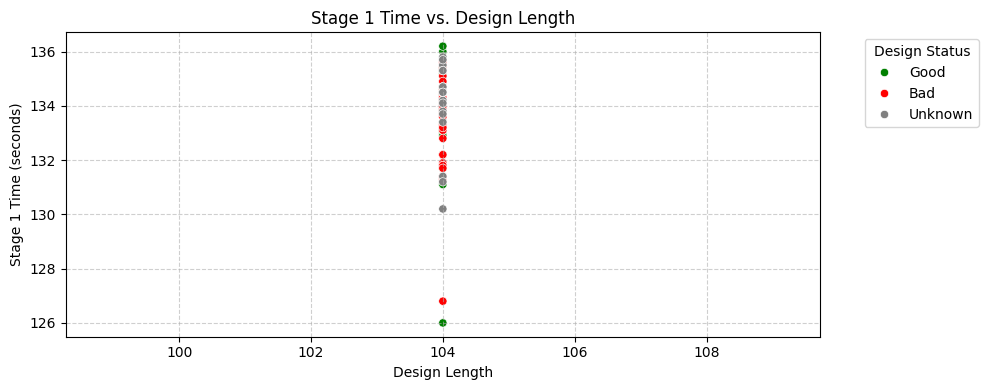

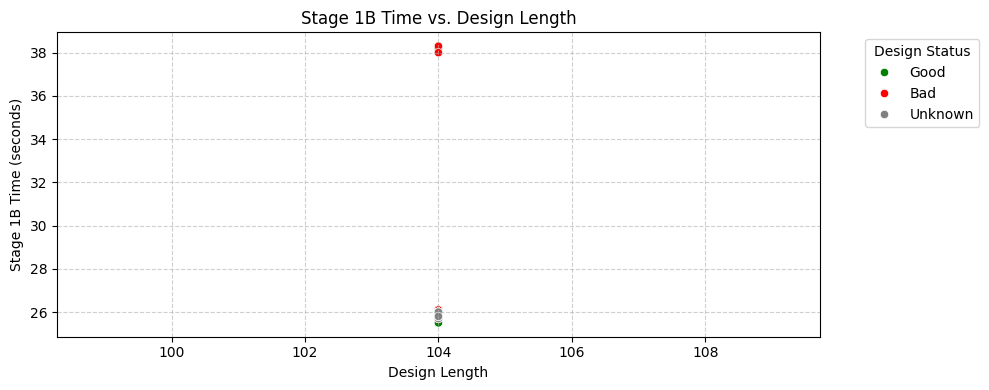

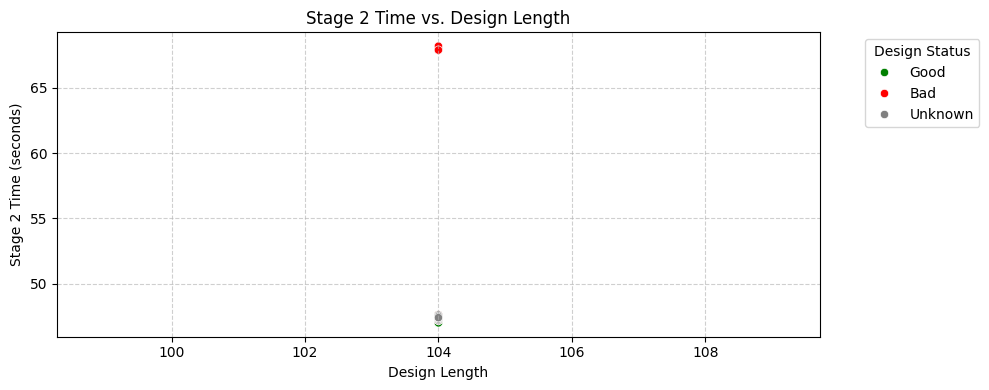

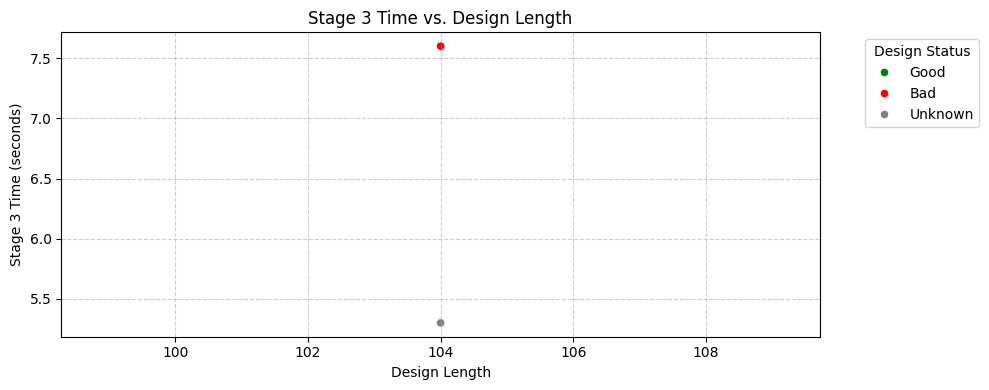

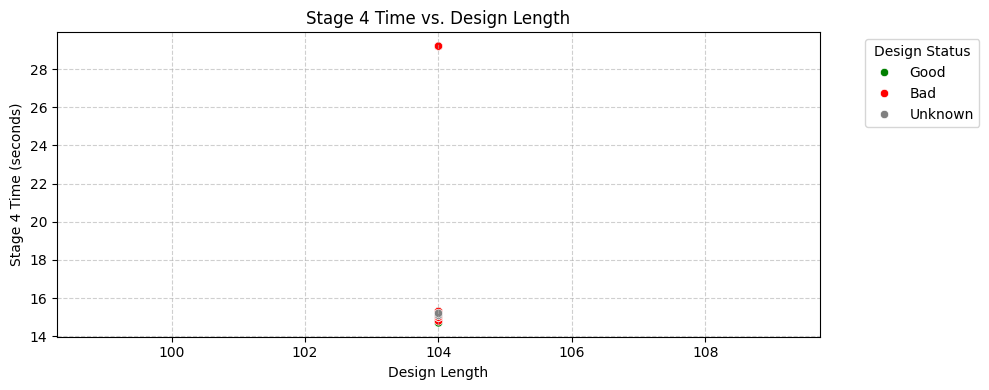

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Map values to strings to ensure the legend and palette match perfectly
plot_df = df.copy()
plot_df['Status'] = plot_df['Good'].map({1.0: 'Good', 0.0: 'Bad', True: 'Good', False: 'Bad'}).fillna('Unknown')

# List of stage labels for titles
stage_labels = ['1', '1B', '2', '3', '4']

for stage_idx in range(5):
    stage_name = stage_labels[stage_idx]
    current_stage_time = plot_df['Stage Time'].apply(lambda x: x[stage_idx] if isinstance(x, list) and len(x) > stage_idx else np.nan)

    plt.figure(figsize=(10, 4))
    sns.scatterplot(
        data=plot_df,
        x='Length',
        y=current_stage_time,
        hue='Status',
        palette={'Good': 'green', 'Bad': 'red', 'Unknown': 'gray'}
    )

    plt.title(f'Stage {stage_name} Time vs. Design Length')
    plt.xlabel('Design Length')
    plt.ylabel(f'Stage {stage_name} Time (seconds)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Design Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# PCA Analysis

### Iteractive Individual Design Trajectories

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from ipywidgets import interact, IntSlider

# Get sequence matrix from the first design
traj_data = df.iloc[33]['Seqmatrix']
traj_data = traj_data[:125] if traj_data.shape[0] > 125 else traj_data

design_name = df.iloc[33]['Design']
num_iterations = traj_data.shape[0]

# ------------------------------------------------------------------
# Each iteration (L, 19) -> flatten to one vector (1, L*19)
# ------------------------------------------------------------------
X = traj_data.reshape(num_iterations, -1)

# PCA across all iterations
pca = PCA(n_components=2)
traj_2d = pca.fit_transform(X)

print(f"Original shape: {traj_data.shape}")
print(f"Flattened shape: {X.shape}")
print(f"PCA shape: {traj_2d.shape}")

# ------------------------------------------------------------------
# Interactive trajectory plot
# ------------------------------------------------------------------
def plot_trajectory(step):
    plt.figure(figsize=(10, 8))

    # Full trajectory
    plt.plot(
        traj_2d[:, 0],
        traj_2d[:, 1],
        color='lightgray',
        linestyle='--',
        alpha=0.5
    )

    # Path up to current step
    plt.plot(
        traj_2d[:step + 1, 0],
        traj_2d[:step + 1, 1],
        '-o',
        color='blue',
        markersize=4,
        alpha=0.8,
        label=f'Trajectory up to iter {step}'
    )

    # Start point
    plt.scatter(
        traj_2d[0, 0],
        traj_2d[0, 1],
        c='red',
        marker='x',
        s=150,
        linewidths=3,
        label='Start'
    )

    # Current point
    plt.scatter(
        traj_2d[step, 0],
        traj_2d[step, 1],
        c='green',
        marker='*',
        s=250,
        label=f'Iteration {step}'
    )

    plt.xlabel(
        f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)'
    )
    plt.ylabel(
        f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)'
    )
    plt.title(f'PCA Optimization Trajectory: {design_name}')
    plt.legend()
    plt.grid(True)

    plt.xlim(
        traj_2d[:, 0].min() - 1,
        traj_2d[:, 0].max() + 1
    )
    plt.ylim(
        traj_2d[:, 1].min() - 1,
        traj_2d[:, 1].max() + 1
    )

    plt.show()

interact(
    plot_trajectory,
    step=IntSlider(
        min=0,
        max=num_iterations - 1,
        step=1,
        value=0,
        description='Iteration'
    )
);

Original shape: (125, 104, 19)
Flattened shape: (125, 1976)
PCA shape: (125, 2)


interactive(children=(IntSlider(value=0, description='Iteration', max=124), Output()), _dom_classes=('widget-i…

### Individual Design Trajectories
We will now perform PCA on each design's `Seqmatrix` individually and plot their trajectories. Each plot represents the optimization path of a single design in 2D space.

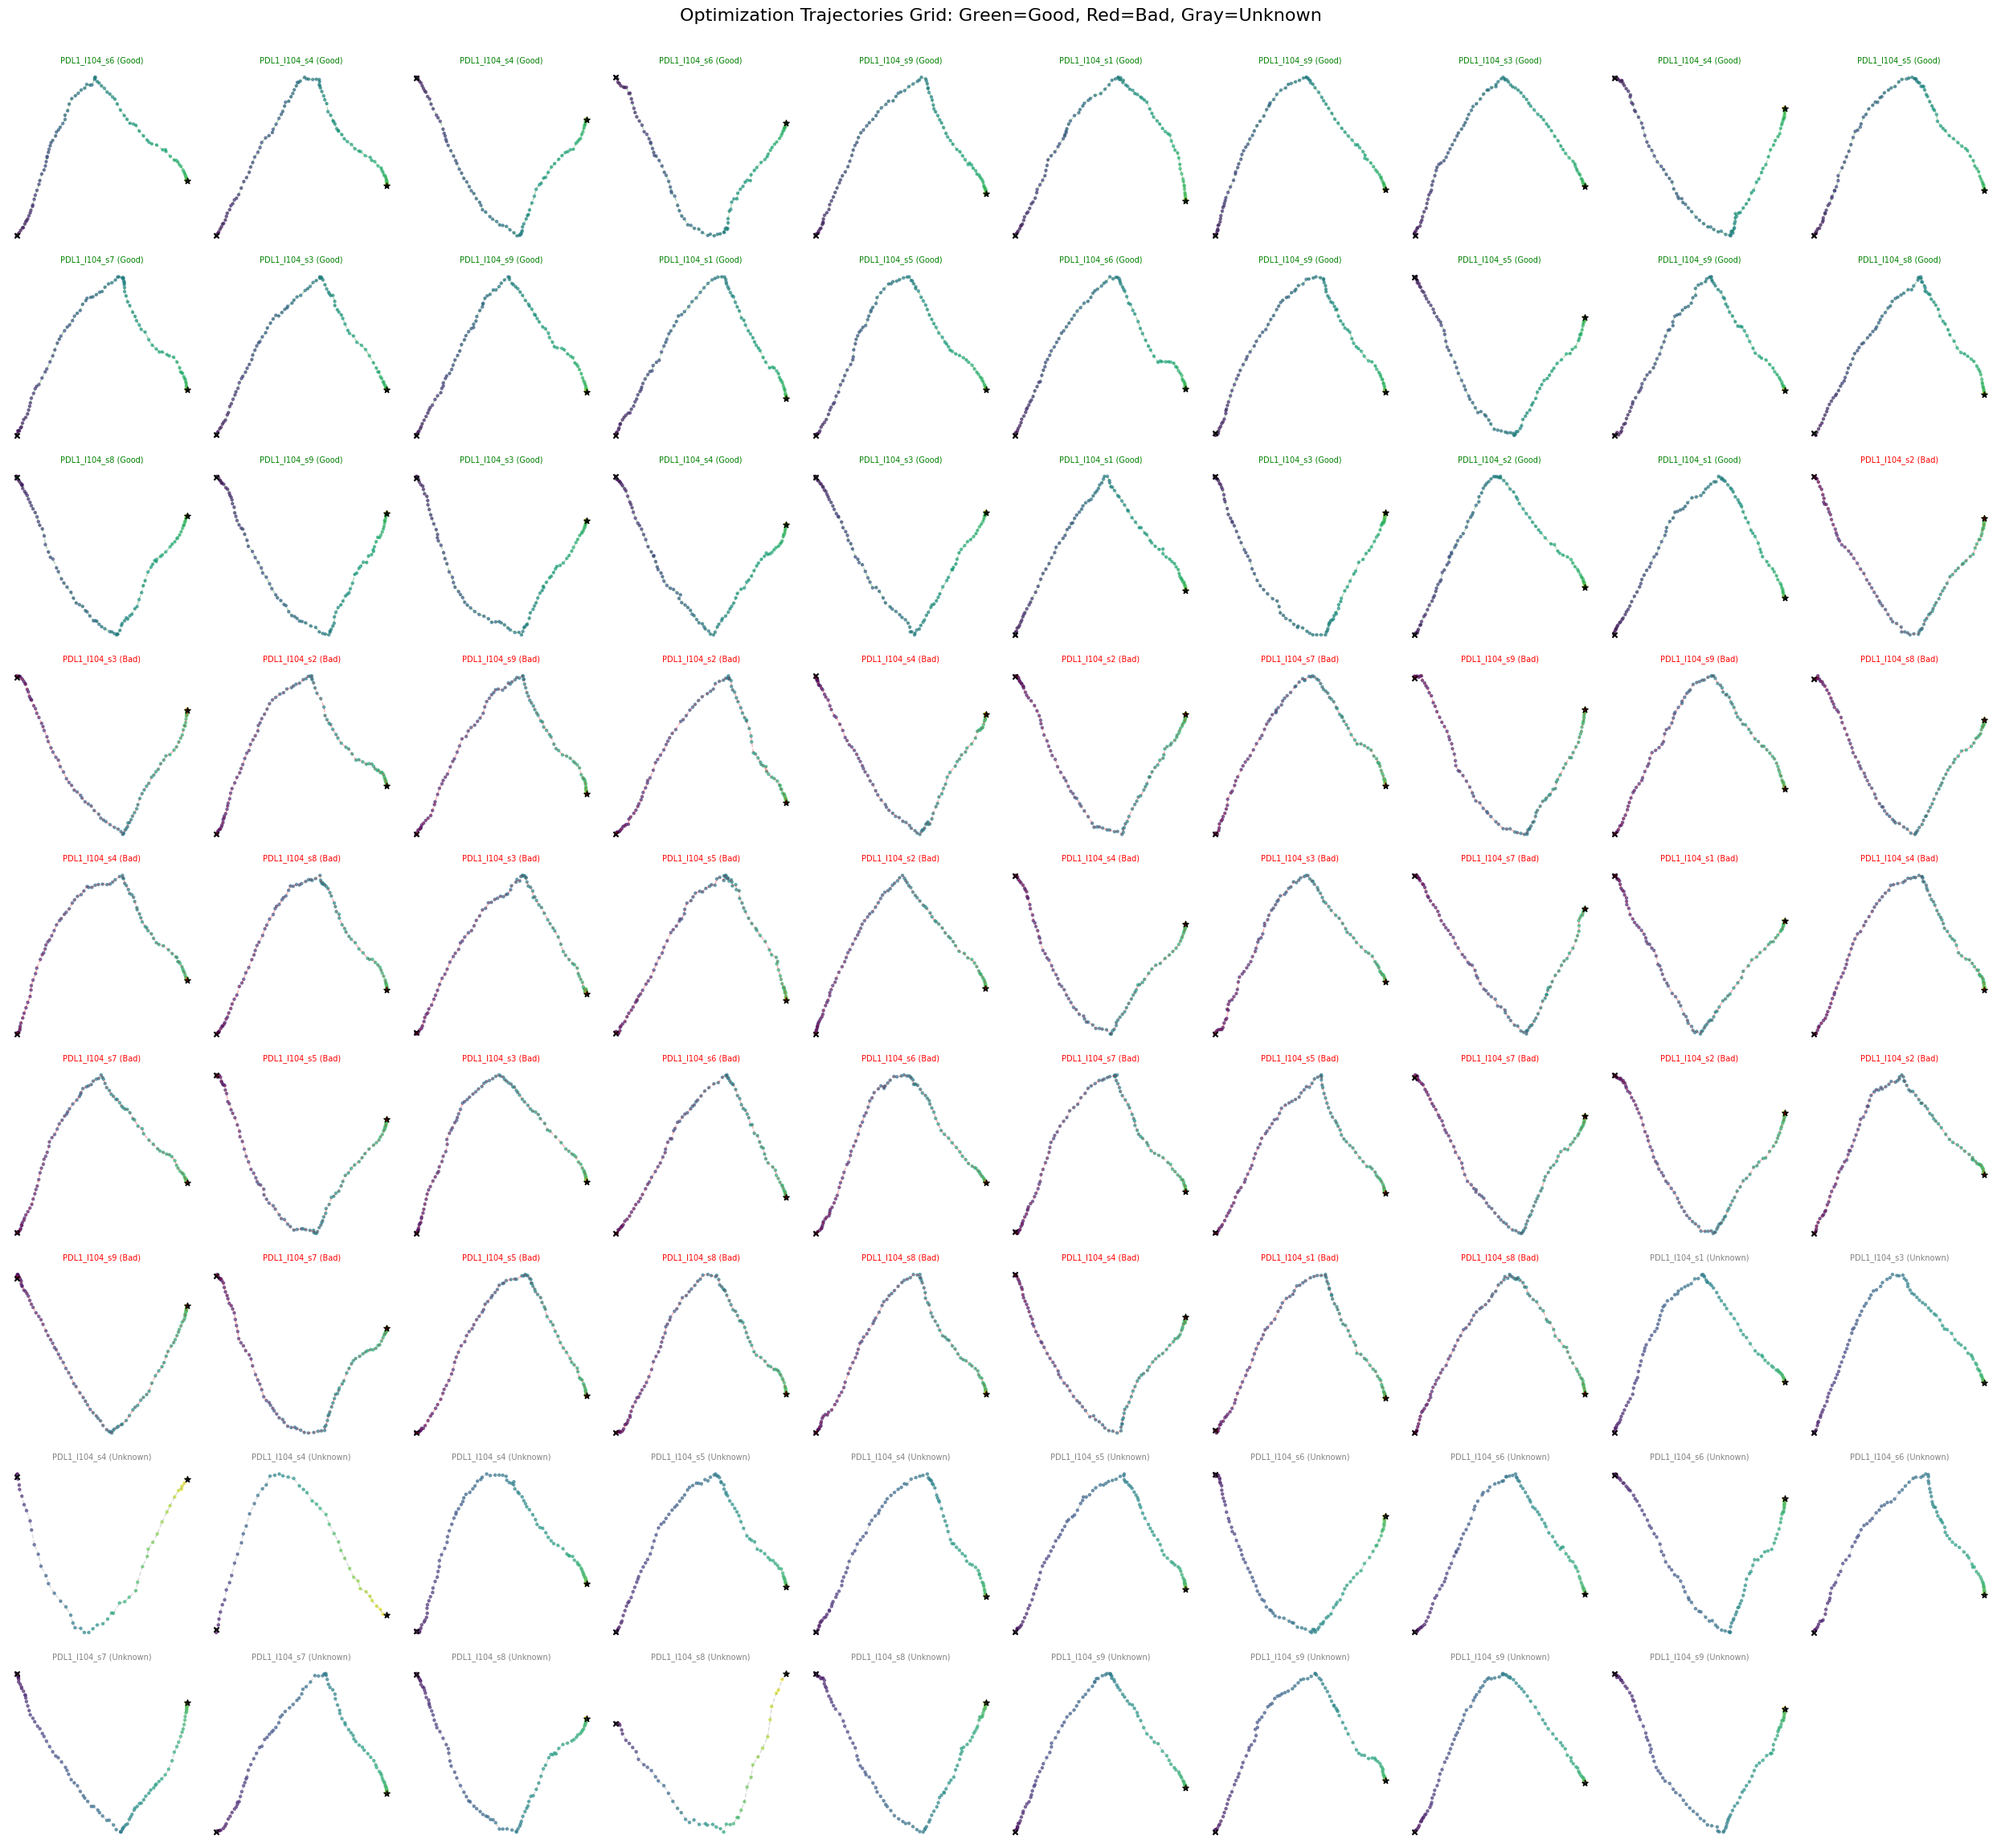

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import math

def plot_all_trajectories_grid(df, max_plots=98, grid_cols=10):
    subset_df = df.head(max_plots)
    num_plots = len(subset_df)
    grid_rows = math.ceil(num_plots / grid_cols)

    # Create a massive figure
    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(25, 2.5 * grid_rows))
    axes = axes.flatten()

    for i, (idx, row) in enumerate(subset_df.iterrows()):
        ax = axes[i]
        traj_data = row['Seqmatrix']
        traj_data = traj_data[:125] if traj_data.shape[0] > 125 else traj_data

        # Update status and color assignment
        if row['Good'] == 1.0 or row['Good'] is True:
            status = "Good"
            color = "green"
        elif row['Good'] == 0.0 or row['Good'] is False:
            status = "Bad"
            color = "red"
        else:
            status = "Unknown"
            color = "gray"

        # Reshape and Fit PCA
        num_iterations = traj_data.shape[0]
        X = traj_data.reshape(num_iterations, -1)
        pca = PCA(n_components=2)
        traj_2d = pca.fit_transform(X)

        # Plot on specific subplot
        ax.plot(traj_2d[:, 0], traj_2d[:, 1], color=color, alpha=0.3, linestyle='--', linewidth=1)
        # Using viridis dots to show progression over time
        ax.scatter(traj_2d[:, 0], traj_2d[:, 1], c=range(num_iterations), cmap='viridis', s=5, alpha=0.6)

        # Markers for Start and End
        ax.scatter(traj_2d[0, 0], traj_2d[0, 1], c='black', marker='x', s=20)
        ax.scatter(traj_2d[-1, 0], traj_2d[-1, 1], c='black', marker='*', s=30)

        ax.set_title(f"{row['Design'][:12]} ({status})", fontsize=7, color=color)
        ax.axis('off')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.suptitle(f"Optimization Trajectories Grid: Green=Good, Red=Bad, Gray=Unknown", fontsize=16, y=1.02)
    plt.show()

# Visualize the full population in a colored 10x10-style grid
plot_all_trajectories_grid(df, max_plots=98, grid_cols=10)

### Combined Population PCA Trajectories
This plot shows multiple design trajectories in the same PCA space. Each line represents the evolution of a design's sequence matrix, limited to the first 125 iterations.

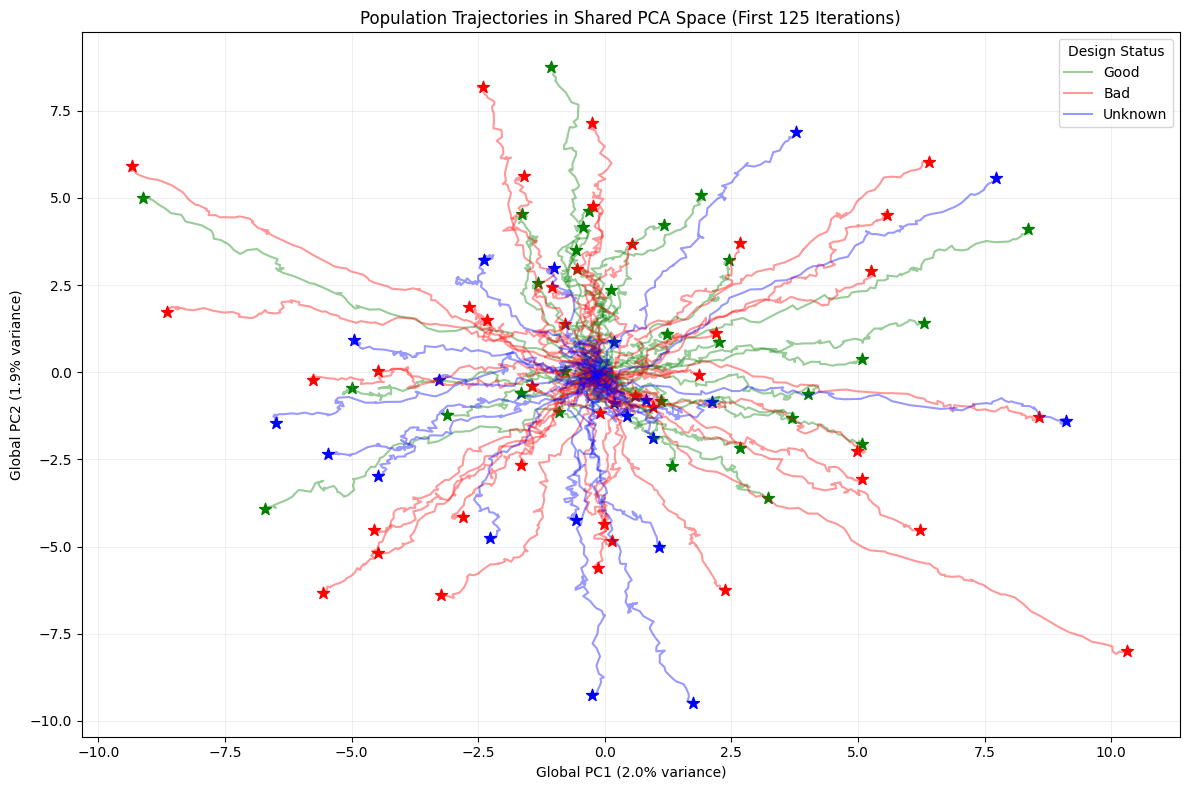

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

def plot_combined_trajectories_shared_pca(df, max_designs=15, max_iters=125):
    subset_df = df.head(max_designs).copy()

    # 1. Identify max length to handle inconsistent dimensions
    max_len = max(row['Seqmatrix'].shape[1] for _, row in subset_df.iterrows())
    num_features = subset_df.iloc[0]['Seqmatrix'].shape[2]

    all_points = []
    design_trajs_padded = []

    for idx, row in subset_df.iterrows():
        traj = row['Seqmatrix'][:max_iters]
        iters, current_len, feats = traj.shape

        if current_len < max_len:
            padding = np.zeros((iters, max_len - current_len, feats))
            traj = np.concatenate([traj, padding], axis=1)

        flattened = traj.reshape(iters, -1)
        all_points.append(flattened)
        design_trajs_padded.append(flattened)

    X_global = np.vstack(all_points)
    pca = PCA(n_components=2)
    pca.fit(X_global)

    # 2. Plotting
    plt.figure(figsize=(12, 8))

    # Define color map for status
    status_colors = {"Good": "green", "Bad": "red", "Unknown": "blue"}

    # Track labels added to legend to avoid duplicates
    legend_handles = {}

    for i, (idx, row) in enumerate(subset_df.iterrows()):
        X_individual = design_trajs_padded[i]
        traj_2d = pca.transform(X_individual)

        # Map status to color
        status = "Good" if row['Good'] == 1.0 else "Bad" if row['Good'] == 0.0 else "Unknown"
        color = status_colors[status]

        # Plot path
        line, = plt.plot(traj_2d[:, 0], traj_2d[:, 1], alpha=0.4, color=color)
        if status not in legend_handles:
            legend_handles[status] = line

        # Start/End markers
        plt.scatter(traj_2d[0, 0], traj_2d[0, 1], marker='x', s=30, color=color, alpha=0.5)
        plt.scatter(traj_2d[-1, 0], traj_2d[-1, 1], marker='*', s=80, color=color)

    plt.title(f"Population Trajectories in Shared PCA Space (First {max_iters} Iterations)")
    plt.xlabel(f"Global PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)")
    plt.ylabel(f"Global PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)")

    # Create a clean legend based on status
    plt.legend(legend_handles.values(), legend_handles.keys(), title="Design Status")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

# Visualize more designs to see the grouping effect
plot_combined_trajectories_shared_pca(df, max_designs=98, max_iters=125)

### UMAP (Uniform Manifold Approximation and Projection)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Flattened shape: (125, 1976)
UMAP shape: (125, 2)


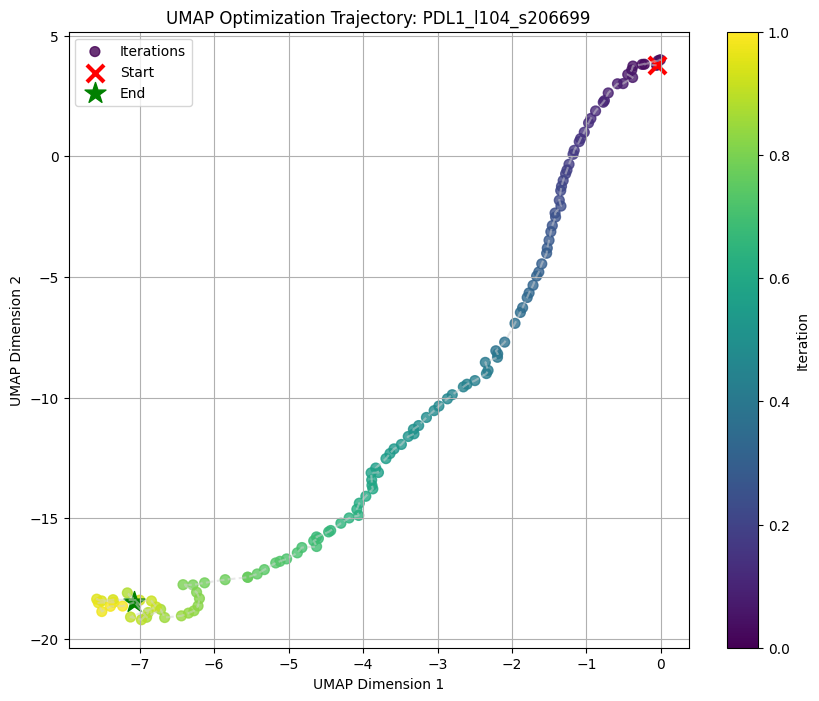

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap

traj_data = df.iloc[4]['Seqmatrix']
traj_data = traj_data[:125] if traj_data.shape[0] > 125 else traj_data
num_iterations = traj_data.shape[0]
X = traj_data.reshape(num_iterations, -1)


# Initialize UMAP. You can adjust n_neighbors and min_dist to tune the projection.
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)

# Fit and transform the flattened sequence matrix
traj_2d_umap = reducer.fit_transform(X)

print(f"Flattened shape: {X.shape}")
print(f"UMAP shape: {traj_2d_umap.shape}")

# --- Plotting the UMAP Trajectory ---
plt.figure(figsize=(10, 8))

# Full trajectory line
plt.plot(
    traj_2d_umap[:, 0],
    traj_2d_umap[:, 1],
    color='lightgray',
    linestyle='--',
    alpha=0.5
)

# Plot all points, colored by iteration to show progression
plt.scatter(
    traj_2d_umap[:, 0],
    traj_2d_umap[:, 1],
    c=range(num_iterations),
    cmap='viridis',
    s=50,
    alpha=0.8,
    label='Iterations'
)

# Start point
plt.scatter(
    traj_2d_umap[0, 0],
    traj_2d_umap[0, 1],
    c='red',
    marker='x',
    s=150,
    linewidths=3,
    label='Start'
)

# End point
plt.scatter(
    traj_2d_umap[-1, 0],
    traj_2d_umap[-1, 1],
    c='green',
    marker='*',
    s=250,
    label='End'
)

plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title(f'UMAP Optimization Trajectory: {design_name}')
plt.colorbar(label='Iteration')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from ipywidgets import interact, IntSlider

# Select a design to visualize
design_index = 4
traj_data = df.iloc[design_index]['Seqmatrix']
traj_data = traj_data[:125] if traj_data.shape[0] > 125 else traj_data

design_name = df.iloc[design_index]['Design']
num_iterations = traj_data.shape[0]
X = traj_data.reshape(num_iterations, -1)

# Fit UMAP for this specific trajectory
reducer = umap.UMAP(n_components=2, n_neighbors=min(15, num_iterations-1), min_dist=0.1, random_state=42)
traj_2d_umap = reducer.fit_transform(X)

def plot_umap_trajectory(step):
    plt.figure(figsize=(10, 8))

    # Full trajectory path (ghost line)
    plt.plot(traj_2d_umap[:, 0], traj_2d_umap[:, 1], color='lightgray', linestyle='--', alpha=0.5)

    # Path up to current step
    plt.plot(traj_2d_umap[:step + 1, 0], traj_2d_umap[:step + 1, 1], '-o', color='purple', markersize=4, alpha=0.8, label=f'Trajectory up to iter {step}')

    # Start point
    plt.scatter(traj_2d_umap[0, 0], traj_2d_umap[0, 1], c='red', marker='x', s=150, linewidths=3, label='Start')

    # Current point
    plt.scatter(traj_2d_umap[step, 0], traj_2d_umap[step, 1], c='green', marker='*', s=250, label=f'Iteration {step}')

    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.title(f'Interactive UMAP Optimization Trajectory: {design_name}')
    plt.legend()
    plt.grid(True)

    # Keep axes limits consistent
    plt.xlim(traj_2d_umap[:, 0].min() - 0.5, traj_2d_umap[:, 0].max() + 0.5)
    plt.ylim(traj_2d_umap[:, 1].min() - 0.5, traj_2d_umap[:, 1].max() + 0.5)
    plt.show()

interact(
    plot_umap_trajectory,
    step=IntSlider(min=0, max=num_iterations - 1, step=1, value=0, description='Iteration')
);

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


interactive(children=(IntSlider(value=0, description='Iteration', max=124), Output()), _dom_classes=('widget-i…

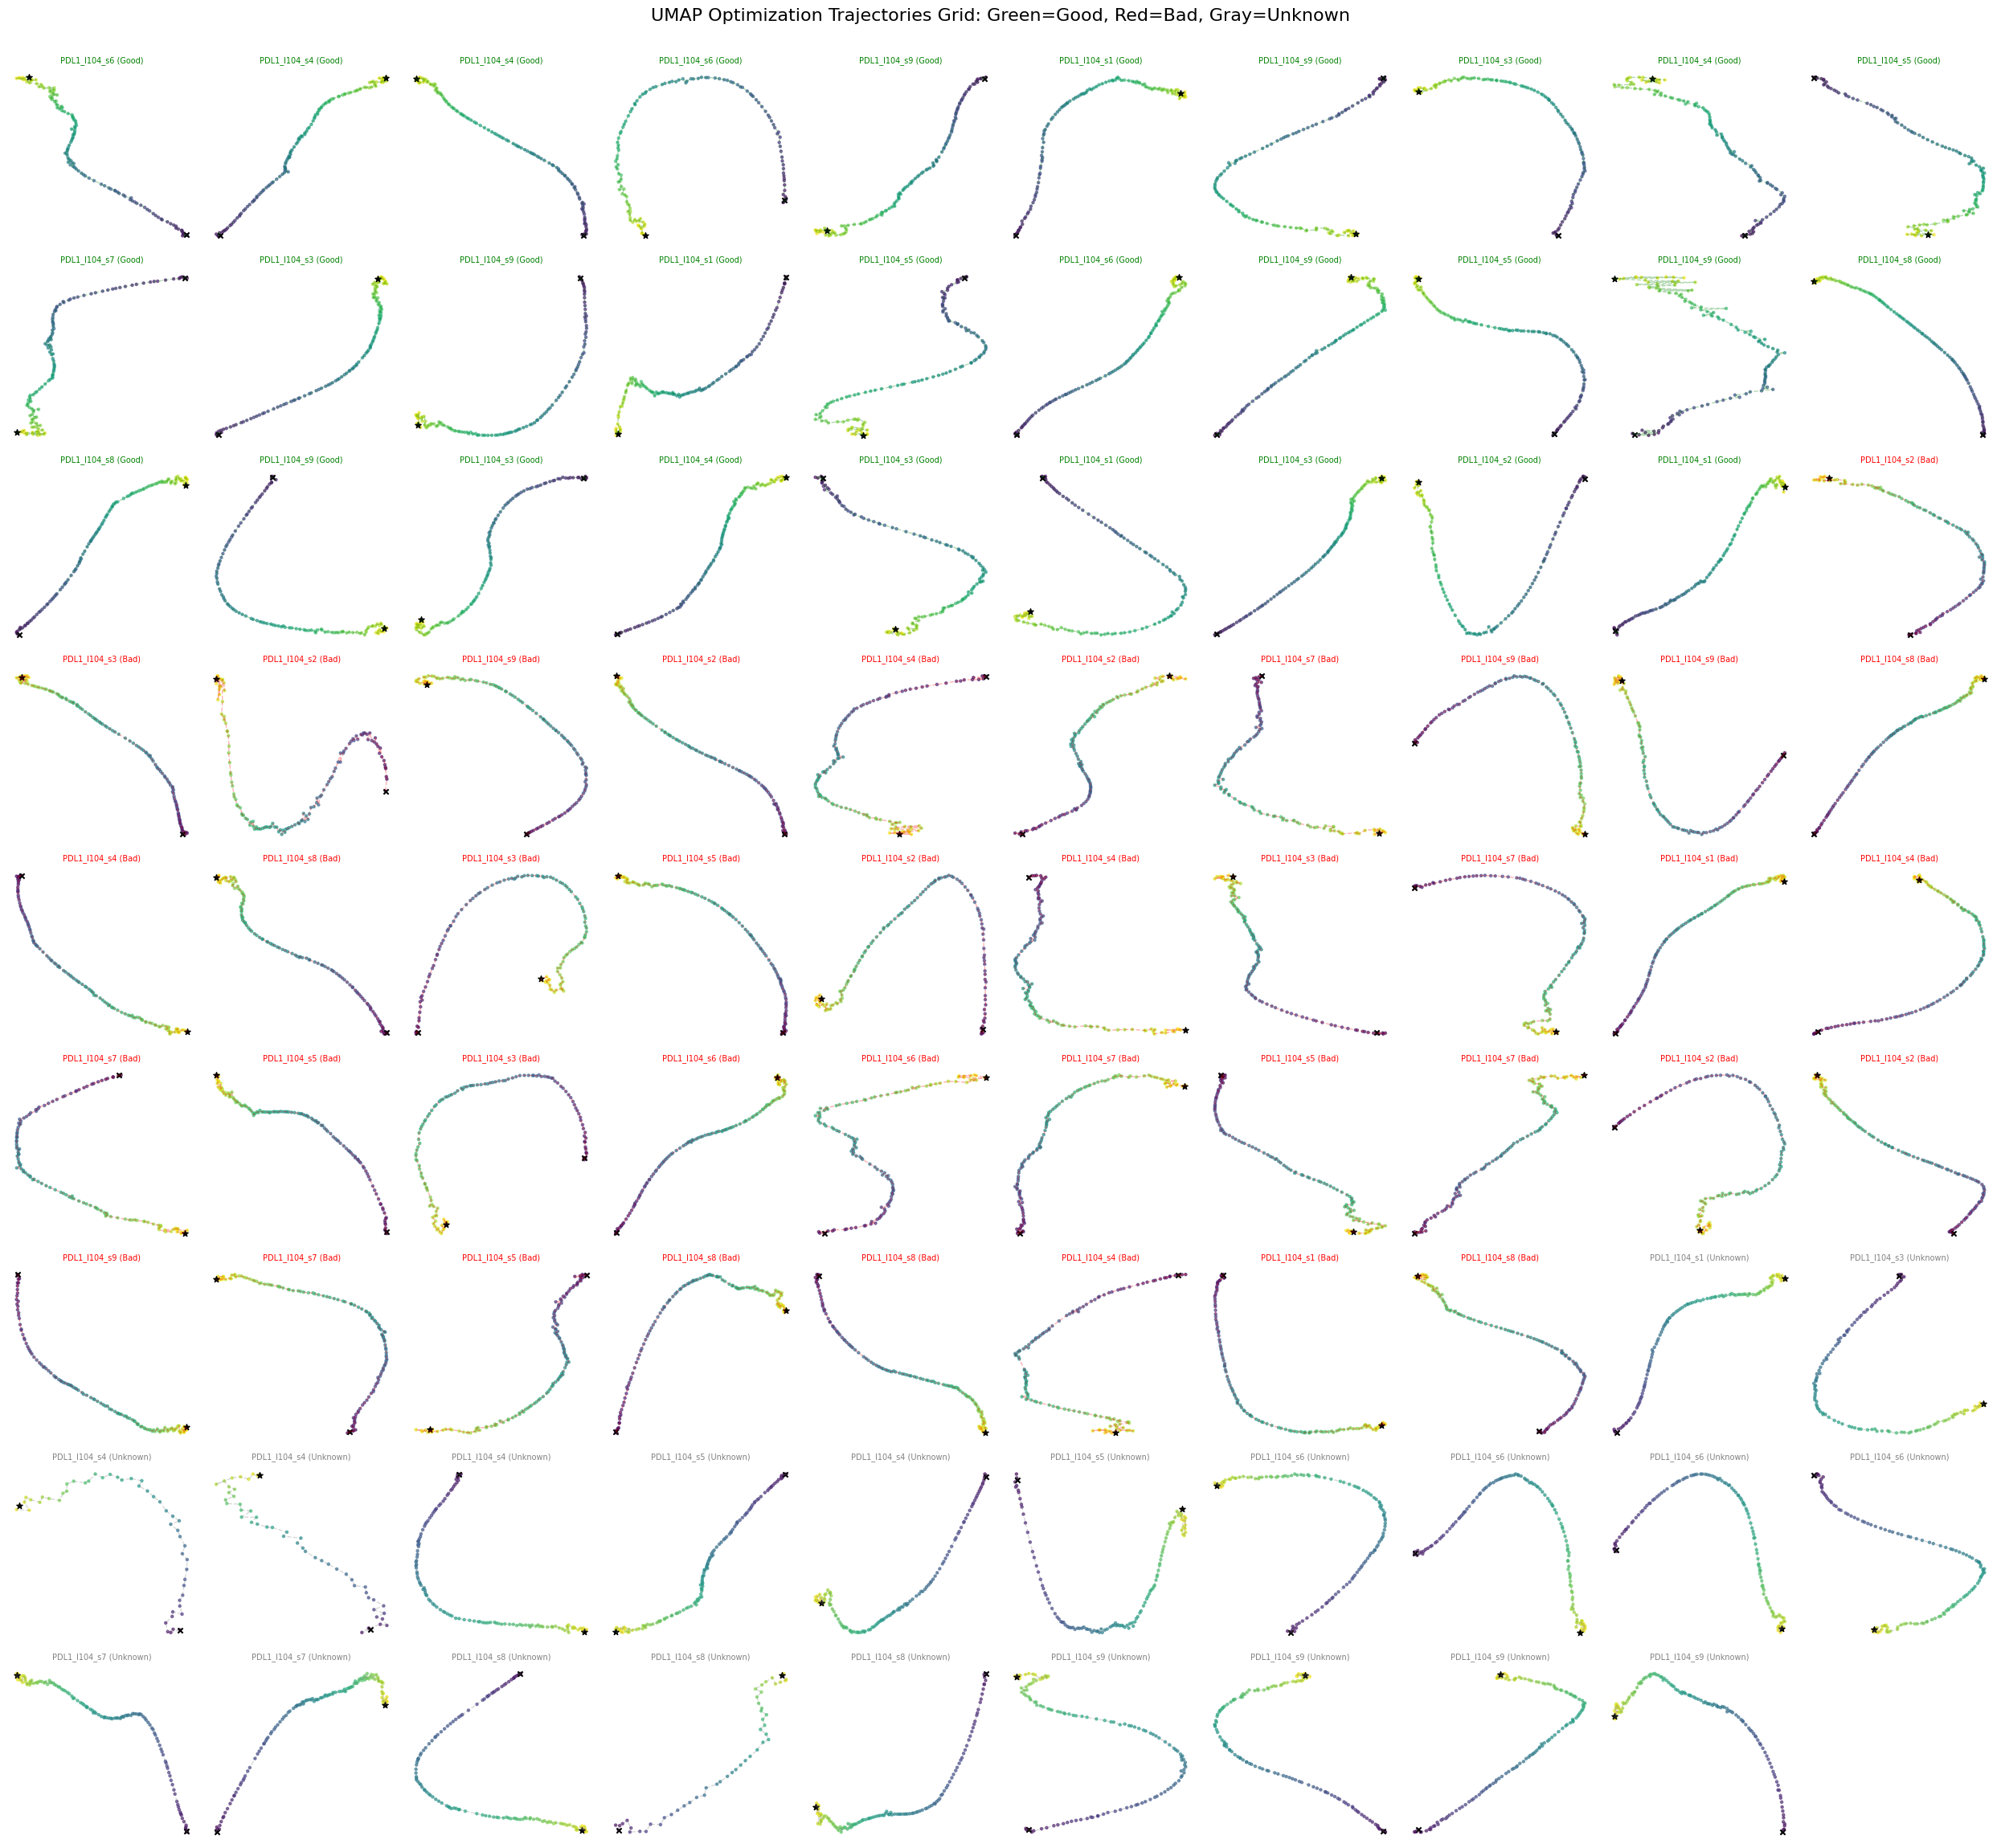

In [ ]:
import matplotlib.pyplot as plt
import umap
import math
import numpy as np
import warnings

# Suppress UMAP parallelism warnings for clean output in loops
warnings.filterwarnings('ignore', message='n_jobs value 1 overridden')

def plot_all_trajectories_umap_grid(df, max_plots=80, grid_cols=10, max_iters=125):
    subset_df = df.head(max_plots)
    num_plots = len(subset_df)
    grid_rows = math.ceil(num_plots / grid_cols)

    # Create a massive figure
    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(25, 2.5 * grid_rows))
    axes = axes.flatten()

    for i, (idx, row) in enumerate(subset_df.iterrows()):
        ax = axes[i]
        traj_data = row['Seqmatrix']
        traj_data = traj_data[:max_iters] if traj_data.shape[0] > max_iters else traj_data

        # Update status and color assignment
        if row['Good'] == 1.0 or row['Good'] is True:
            status = "Good"
            color = "green"
        elif row['Good'] == 0.0 or row['Good'] is False:
            status = "Bad"
            color = "red"
        else:
            status = "Unknown"
            color = "gray"

        # Reshape and Fit UMAP
        num_iterations = traj_data.shape[0]
        X = traj_data.reshape(num_iterations, -1)

        # Using smaller n_neighbors for individual trajectories since points are few
        reducer = umap.UMAP(n_components=2, n_neighbors=min(15, num_iterations-1), min_dist=0.1, random_state=42)
        traj_2d = reducer.fit_transform(X)

        # Plot on specific subplot
        ax.plot(traj_2d[:, 0], traj_2d[:, 1], color=color, alpha=0.3, linestyle='--', linewidth=1)
        # Using viridis dots to show progression over time
        ax.scatter(traj_2d[:, 0], traj_2d[:, 1], c=range(num_iterations), cmap='viridis', s=5, alpha=0.6)

        # Markers for Start and End
        ax.scatter(traj_2d[0, 0], traj_2d[0, 1], c='black', marker='x', s=20)
        ax.scatter(traj_2d[-1, 0], traj_2d[-1, 1], c='black', marker='*', s=30)

        ax.set_title(f"{row['Design'][:12]} ({status})", fontsize=7, color=color)
        ax.axis('off')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.suptitle(f"UMAP Optimization Trajectories Grid: Green=Good, Red=Bad, Gray=Unknown", fontsize=16, y=1.02)
    plt.show()

# Visualize the trajectories using UMAP
plot_all_trajectories_umap_grid(df, max_plots=89, grid_cols=10)

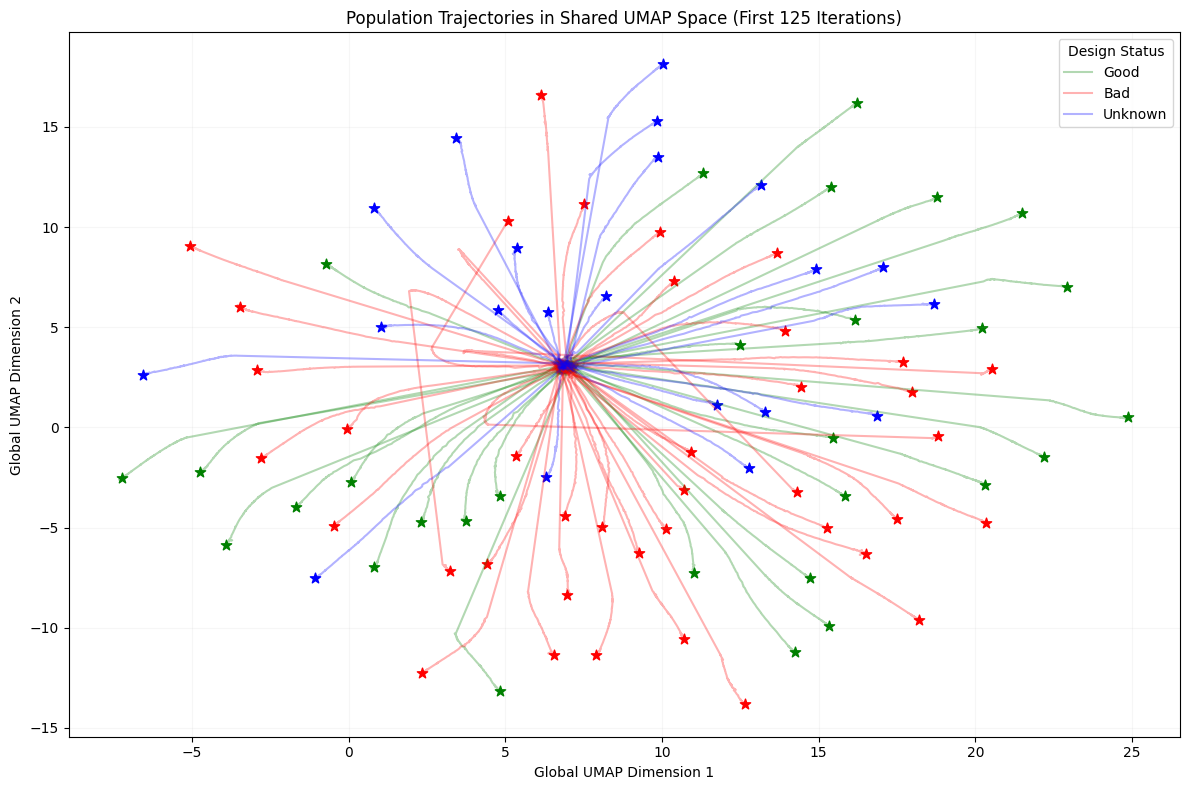

In [ ]:
import matplotlib.pyplot as plt
import umap
import numpy as np
import warnings

# Suppress UMAP parallelism warnings
warnings.filterwarnings('ignore', message='n_jobs value 1 overridden')

def plot_combined_trajectories_shared_umap(df, max_designs=30, max_iters=125):
    subset_df = df.head(max_designs).copy()

    # 1. Identify max length to handle inconsistent dimensions for padding
    max_len = max(row['Seqmatrix'].shape[1] for _, row in subset_df.iterrows())
    num_features = subset_df.iloc[0]['Seqmatrix'].shape[2]

    all_points = []
    design_trajs_padded = []

    for idx, row in subset_df.iterrows():
        traj = row['Seqmatrix'][:max_iters]
        iters, current_len, feats = traj.shape

        if current_len < max_len:
            padding = np.zeros((iters, max_len - current_len, feats))
            traj = np.concatenate([traj, padding], axis=1)

        flattened = traj.reshape(iters, -1)
        all_points.append(flattened)
        design_trajs_padded.append(flattened)

    # Combine all points into one matrix to fit the UMAP space
    X_global = np.vstack(all_points)

    # Fit UMAP on the whole population
    reducer = umap.UMAP(n_components=2, n_neighbors=30)
    reducer.fit(X_global)

    # 2. Plotting
    plt.figure(figsize=(12, 8))

    # Define color map for status
    status_colors = {True: "green", False: "red", 1.0: "green", 0.0: "red", "Unknown": "gray"}

    # Track labels added to legend to avoid duplicates
    legend_handles = {}

    for i, (idx, row) in enumerate(subset_df.iterrows()):
        X_individual = design_trajs_padded[i]
        traj_2d = reducer.transform(X_individual)

        # Map status to color
        status_val = row['Good']
        color = status_colors.get(status_val, "blue")
        status_label = "Good" if (status_val == 1.0 or status_val is True) else "Bad" if (status_val == 0.0 or status_val is False) else "Unknown"

        # Plot path
        line, = plt.plot(traj_2d[:, 0], traj_2d[:, 1], alpha=0.3, color=color)
        if status_label not in legend_handles:
            legend_handles[status_label] = line

        # Start/End markers
        plt.scatter(traj_2d[0, 0], traj_2d[0, 1], marker='x', s=20, color=color, alpha=0.4)
        plt.scatter(traj_2d[-1, 0], traj_2d[-1, 1], marker='*', s=60, color=color)

    plt.title(f"Population Trajectories in Shared UMAP Space (First {max_iters} Iterations)")
    plt.xlabel("Global UMAP Dimension 1")
    plt.ylabel("Global UMAP Dimension 2")

    # Create a clean legend based on status
    plt.legend(legend_handles.values(), legend_handles.keys(), title="Design Status")
    plt.grid(True, alpha=0.1)
    plt.tight_layout()
    plt.show()

# Visualize the population in a shared UMAP manifold
plot_combined_trajectories_shared_umap(df, max_designs=89, max_iters=125)

# Loss


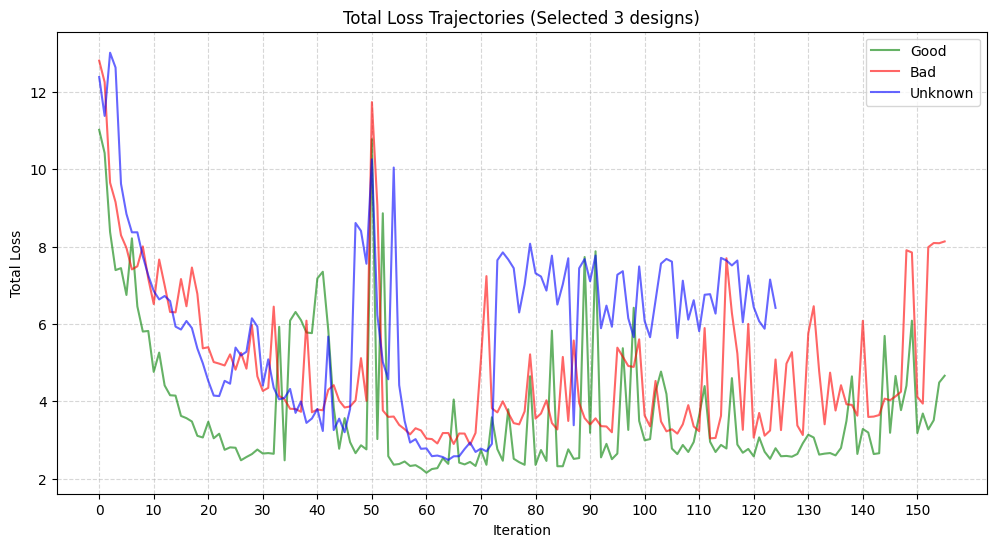

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# SETTINGS: Define which designs to plot
# Examples: range(0, 20), [1, 5, 10, 22], or None for all
designs_to_plot = range(98)
designs_to_plot = [1, 30, 88]
use_log_scale = False

# Filter the dataframe based on selection
if designs_to_plot is not None:
    plot_df = df.iloc[list(designs_to_plot)]
else:
    plot_df = df

plt.figure(figsize=(12, 6))

# Define color and label mapping logic
# We use blue for NaN/Unknown values as requested
color_map = {True: 'green', False: 'red', 1.0: 'green', 0.0: 'red'}
label_map = {True: 'Good', False: 'Bad', 1.0: 'Good', 0.0: 'Bad'}

added_labels = set()

for i, (idx, row) in enumerate(plot_df.iterrows()):
    loss_values = row['total_loss']
    status = row['Good']

    # Determine color: default to blue if status is not 1/0/True/False
    color = color_map.get(status, 'blue')
    label = label_map.get(status, 'Unknown')

    # Plotting logic with legend handling
    if label not in added_labels:
        plt.plot(loss_values, color=color, alpha=0.6, label=label, linewidth=1.5)
        added_labels.add(label)
    else:
        plt.plot(loss_values, color=color, alpha=0.6, linewidth=1.5)

plt.title(f'Total Loss Trajectories (Selected {len(plot_df)} designs)')
plt.xlabel('Iteration')
plt.ylabel('Total Loss')
plt.xticks(range(0, 151, 10))

if use_log_scale:
    plt.yscale('log')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

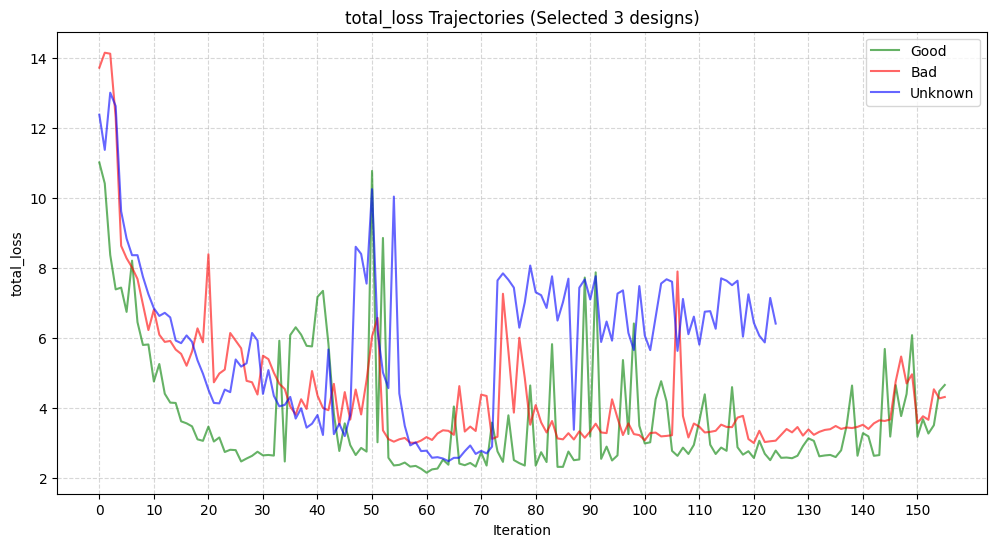

/tmp/ipykernel_5485/2807864101.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


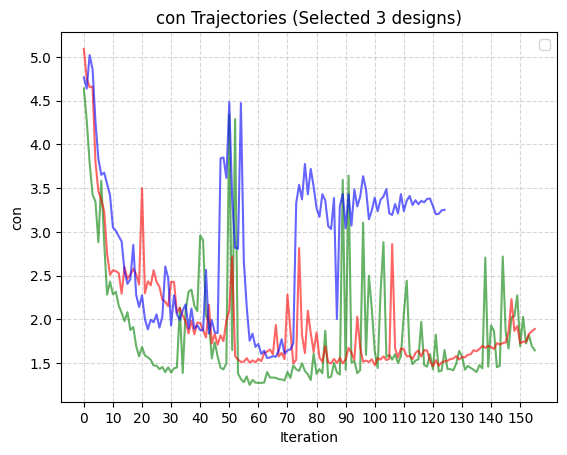

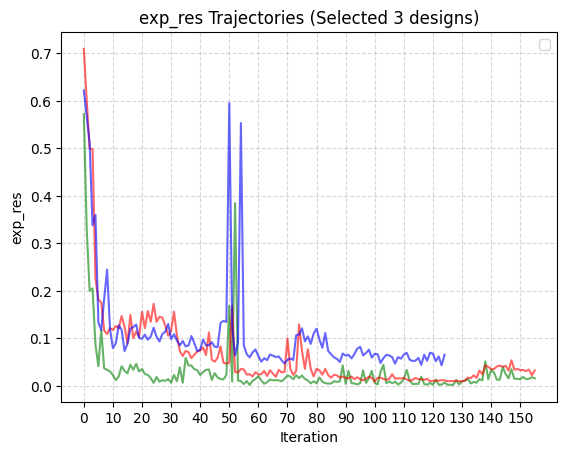

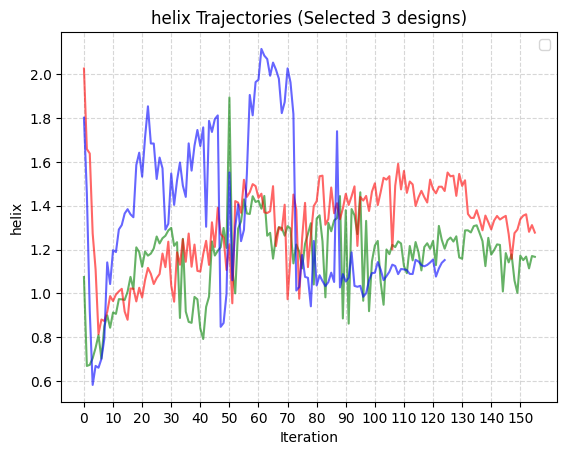

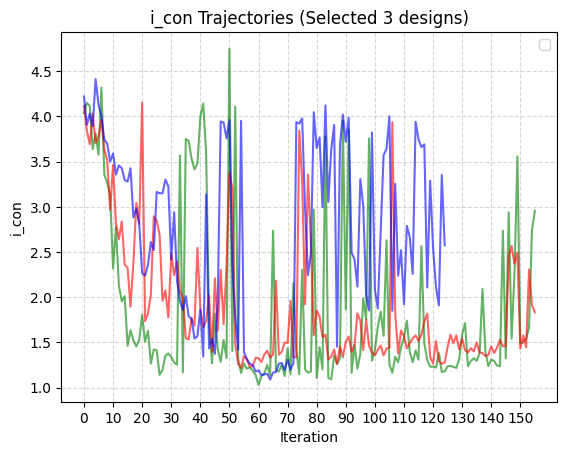

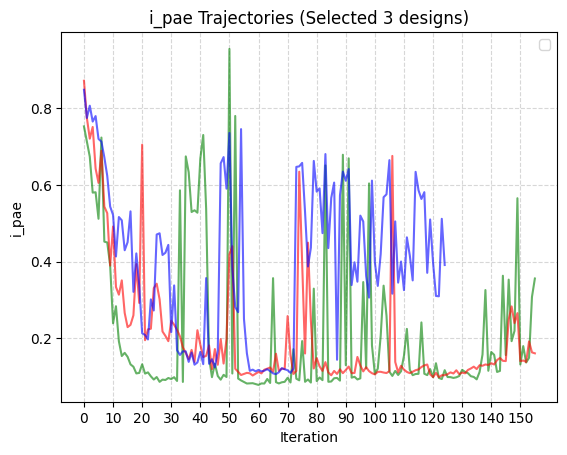

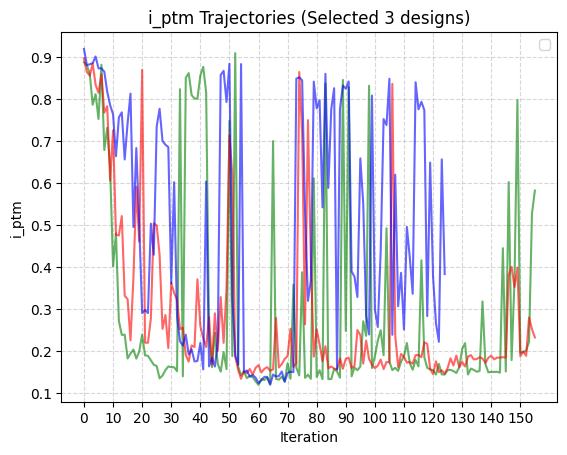

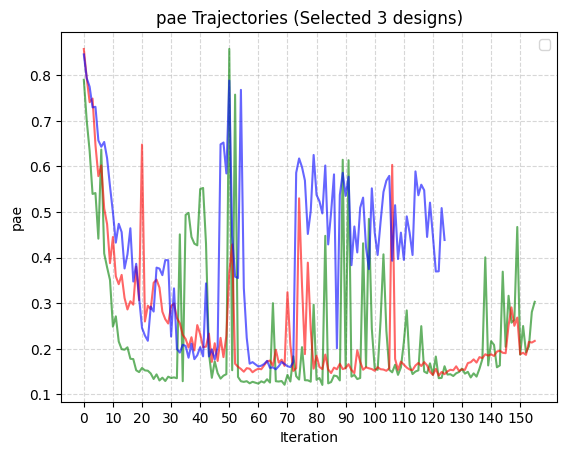

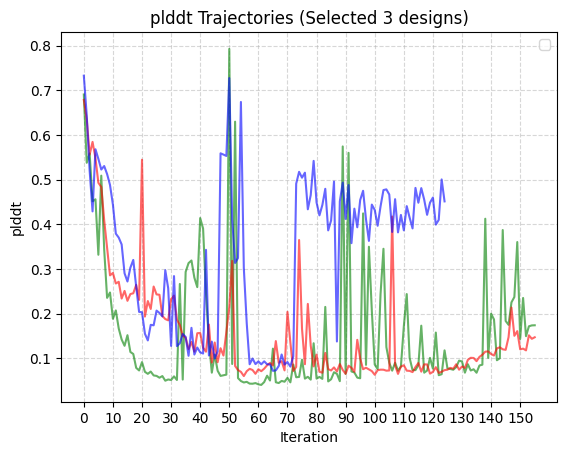

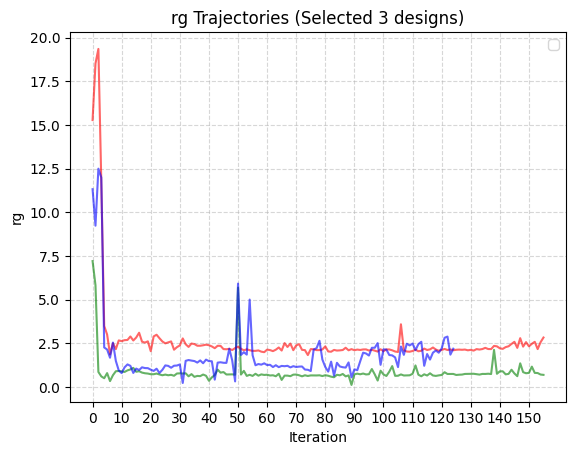

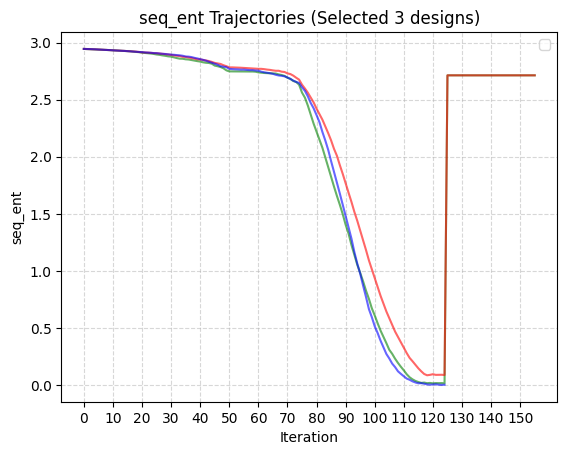

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# SETTINGS: Define which designs to plot
# Examples: range(0, 20), [1, 5, 10, 22], or None for all
designs_to_plot = range(89)
designs_to_plot = [1,40,88]
use_log_scale = False

# Filter the dataframe based on selection
if designs_to_plot is not None:
    plot_df = df.iloc[list(designs_to_plot)]
else:
    plot_df = df

plt.figure(figsize=(12, 6))

# Define color and label mapping logic
# We use blue for NaN/Unknown values as requested
color_map = {True: 'green', False: 'red', 1.0: 'green', 0.0: 'red'}
label_map = {True: 'Good', False: 'Bad', 1.0: 'Good', 0.0: 'Bad'}

added_labels = set()

def plot(loss):
  for i, (idx, row) in enumerate(plot_df.iterrows()):
      loss_values = row[loss]
      status = row['Good']

      # Determine color: default to blue if status is not 1/0/True/False
      color = color_map.get(status, 'blue')
      label = label_map.get(status, 'Unknown')

      # Plotting logic with legend handling
      if label not in added_labels:
          plt.plot(loss_values, color=color, alpha=0.6, label=label, linewidth=1.5)
          added_labels.add(label)
      else:
          plt.plot(loss_values, color=color, alpha=0.6, linewidth=1.5)

  plt.title(f'{loss} Trajectories (Selected {len(plot_df)} designs)')
  plt.xlabel('Iteration')
  plt.ylabel(f'{loss}')
  plt.xticks(range(0, 151, 10))

  if use_log_scale:
      plt.yscale('log')

  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.show()

for loss in list(df.columns)[5:]:
  plot(loss)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import math

def plot_metric_pca_grid(df, metric_col, max_plots=89, grid_cols=10):
    subset_df = df.head(max_plots)
    num_plots = len(subset_df)
    grid_rows = math.ceil(num_plots / grid_cols)

    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(25, 2.5 * grid_rows))
    axes = axes.flatten()

    for i, (idx, row) in enumerate(subset_df.iterrows()):
        ax = axes[i]
        # Data in these columns are lists of values over iterations
        data = np.array(row[metric_col]).reshape(-1, 1)

        if len(data) < 2:
            ax.axis('off')
            continue

        # Standardize color logic
        status_val = row['Good']
        color = 'green' if (status_val == 1.0 or status_val is True) else 'red' if (status_val == 0.0 or status_val is False) else 'gray'

        # Since these are 1D metrics, PCA(n_components=1) is trivial.
        # To visualize the 'trajectory', we plot Iteration vs Metric Value
        iterations = np.arange(len(data))
        ax.plot(iterations, data, color=color, alpha=0.6)
        ax.scatter(iterations[0], data[0], c='black', marker='x', s=20)
        ax.scatter(iterations[-1], data[-1], c='black', marker='*', s=30)

        ax.set_title(f"{row['Design'][:10]}", fontsize=8)
        ax.axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"Metric Trajectories: {metric_col} (Green=Good, Red=Bad)", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# Loop through all metric columns starting from index 5
metrics_to_analyze = list(df.columns)[5:]
print(f"Analyzing metrics: {metrics_to_analyze}")

# Example: Plotting the first one, total_loss
plot_metric_pca_grid(df, 'total_loss')

# If you want to see all of them, you can uncomment the loop below:
# for metric in metrics_to_analyze:
#     plot_metric_pca_grid(df, metric)

### Global Population PCA: Sequence + All Metrics
This analysis combines the `Seqmatrix` and all scalar metrics into one unified feature vector per iteration to observe the global optimization manifold.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

def plot_mega_combined_pca(df, max_designs=89, max_iters=125):
    subset_df = df.head(max_designs).copy()
    metric_cols = ['total_loss', 'con', 'exp_res', 'helix', 'i_con', 'i_pae', 'i_ptm', 'pae', 'plddt', 'rg', 'seq_ent']

    # 1. Prepare data: Combine Sequence + Metrics
    max_len = max(row['Seqmatrix'].shape[1] for _, row in subset_df.iterrows())
    num_features = subset_df.iloc[0]['Seqmatrix'].shape[2]

    all_combined_points = []
    design_indices = []

    for idx, row in subset_df.iterrows():
        seq_traj = row['Seqmatrix'][:max_iters]
        iters = seq_traj.shape[0]

        # Pad sequence matrix if necessary
        if seq_traj.shape[1] < max_len:
            padding = np.zeros((iters, max_len - seq_traj.shape[1], num_features))
            seq_traj = np.concatenate([seq_traj, padding], axis=1)

        # Flatten sequence: (iters, L*19)
        seq_flat = seq_traj.reshape(iters, -1)

        # Collect metrics: (iters, num_metrics)
        metric_list = []
        for col in metric_cols:
            m_values = np.array(row[col][:max_iters]).reshape(-1, 1)
            # Ensure metric length matches iters (pad with last value if shorter)
            if len(m_values) < iters:
                m_values = np.pad(m_values, ((0, iters - len(m_values)), (0, 0)), mode='edge')
            metric_list.append(m_values)

        metrics_flat = np.hstack(metric_list)

        # Combine Sequence + Metrics: (iters, (L*19) + num_metrics)
        combined = np.hstack([seq_flat, metrics_flat])
        all_combined_points.append(combined)
        design_indices.append((row['Design'], row['Good'], iters))

    X_global = np.vstack(all_combined_points)

    # Scale data because metrics and sequence values have different magnitudes
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_global)

    pca = PCA(n_components=2)
    coords_2d = pca.fit_transform(X_scaled)

    # 2. Plotting
    plt.figure(figsize=(14, 9))
    status_colors = {True: 'green', False: 'red', 1.0: 'green', 0.0: 'red', 'Unknown': 'gray'}

    current_start = 0
    legend_done = set()

    for i, (name, status, iters) in enumerate(design_indices):
        traj_coords = coords_2d[current_start : current_start + iters]
        current_start += iters

        color = status_colors.get(status, 'blue')
        label = 'Good' if status in [True, 1.0] else 'Bad' if status in [False, 0.0] else 'Unknown'

        # Plot trajectory line
        plt.plot(traj_coords[:, 0], traj_coords[:, 1], color=color, alpha=0.2, linewidth=1)

        # Plot start/end
        plt.scatter(traj_coords[0, 0], traj_coords[0, 1], marker='x', color=color, s=20, alpha=0.5)
        plt.scatter(traj_coords[-1, 0], traj_coords[-1, 1], marker='*', color=color, s=50,
                    label=label if label not in legend_done else "")
        legend_done.add(label)

    plt.title(f"Global PCA (Sequence + All Metrics) for {len(subset_df)} Designs")
    plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)")
    plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)")
    plt.legend(title="Design Status")
    plt.grid(True, alpha=0.2)
    plt.show()

plot_mega_combined_pca(df)

### Global Population PCA: Metrics Only (No Sequence)
This analysis combines all scalar metrics into one feature vector per iteration, ignoring the sequence matrix, to observe how the physical and loss properties evolve together across the population.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

def plot_metrics_only_pca(df, max_designs=89, max_iters=125):
    subset_df = df.head(max_designs).copy()
    metric_cols = ['total_loss', 'con', 'exp_res', 'helix', 'i_con', 'i_pae', 'i_ptm', 'pae', 'plddt', 'rg', 'seq_ent']

    all_metric_points = []
    design_indices = []

    for idx, row in subset_df.iterrows():
        iters = len(row['total_loss'][:max_iters])

        # Collect metrics: (iters, num_metrics)
        metric_list = []
        for col in metric_cols:
            m_values = np.array(row[col][:max_iters]).reshape(-1, 1)
            # Ensure metric length matches max_iters if necessary (pad with last value)
            if len(m_values) < iters:
                m_values = np.pad(m_values, ((0, iters - len(m_values)), (0, 0)), mode='edge')
            metric_list.append(m_values)

        # Stack all metrics for this design: (iters, 11)
        metrics_combined = np.hstack(metric_list)
        all_metric_points.append(metrics_combined)
        design_indices.append((row['Design'], row['Good'], iters))

    # Combine everything for global fit: (Total_Iters, 11)
    X_global = np.vstack(all_metric_points)

    # Scale data so different metric magnitudes don't bias PCA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_global)

    pca = PCA(n_components=2)
    coords_2d = pca.fit_transform(X_scaled)

    # 2. Plotting
    plt.figure(figsize=(14, 9))
    status_colors = {True: 'green', False: 'red', 1.0: 'green', 0.0: 'red', 'Unknown': 'gray'}

    current_start = 0
    legend_done = set()

    for i, (name, status, iters) in enumerate(design_indices):
        traj_coords = coords_2d[current_start : current_start + iters]
        current_start += iters

        color = status_colors.get(status, 'blue')
        label = 'Good' if status in [True, 1.0] else 'Bad' if status in [False, 0.0] else 'Unknown'

        # Plot trajectory line
        plt.plot(traj_coords[:, 0], traj_coords[:, 1], color=color, alpha=0.25, linewidth=1)

        # Plot markers
        plt.scatter(traj_coords[0, 0], traj_coords[0, 1], marker='x', color=color, s=20, alpha=0.5)
        plt.scatter(traj_coords[-1, 0], traj_coords[-1, 1], marker='*', color=color, s=60,
                    label=label if label not in legend_done else "")
        legend_done.add(label)

    plt.title(f"Global PCA (Metrics Only) for {len(subset_df)} Designs")
    plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)")
    plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)")
    plt.legend(title="Design Status")
    plt.grid(True, alpha=0.2)
    plt.show()

plot_metrics_only_pca(df)

### Global Population PCA: Interface Metrics Only
This analysis isolates the interface-specific metrics (`i_con`, `i_pae`, and `i_ptm`) to visualize how the binding quality evolves across the population.

In [ ]:
df.columns

Index(['Design', 'Good', 'Seqmatrix', 'Stage Time', 'Length', 'total_loss',
       'con', 'exp_res', 'helix', 'i_con', 'i_pae', 'i_ptm', 'pae', 'plddt',
       'rg', 'seq_ent'],
      dtype='object')

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

def plot_interface_metrics_pca(df, max_designs=89, max_iters=125):
    subset_df = df.head(max_designs).copy()
    # Focusing specifically on interface metrics
    metric_cols = df.columns[6:]

    all_metric_points = []
    design_indices = []

    for idx, row in subset_df.iterrows():
        iters = len(row['total_loss'][:max_iters])

        metric_list = []
        for col in metric_cols:
            m_values = np.array(row[col][:max_iters]).reshape(-1, 1)
            if len(m_values) < iters:
                m_values = np.pad(m_values, ((0, iters - len(m_values)), (0, 0)), mode='edge')
            metric_list.append(m_values)

        metrics_combined = np.hstack(metric_list)
        all_metric_points.append(metrics_combined)
        design_indices.append((row['Design'], row['Good'], iters))

    X_global = np.vstack(all_metric_points)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_global)

    pca = PCA(n_components=2)
    coords_2d = pca.fit_transform(X_scaled)

    plt.figure(figsize=(14, 9))
    status_colors = {True: 'green', False: 'red', 1.0: 'green', 0.0: 'red', 'Unknown': 'gray'}

    current_start = 0
    legend_done = set()

    for i, (name, status, iters) in enumerate(design_indices):
        traj_coords = coords_2d[current_start : current_start + iters]
        current_start += iters

        color = status_colors.get(status, 'blue')
        label = 'Good' if status in [True, 1.0] else 'Bad' if status in [False, 0.0] else 'Unknown'

        plt.plot(traj_coords[:, 0], traj_coords[:, 1], color=color, alpha=0.25, linewidth=1)
        plt.scatter(traj_coords[0, 0], traj_coords[0, 1], marker='x', color=color, s=20, alpha=0.5)
        plt.scatter(traj_coords[-1, 0], traj_coords[-1, 1], marker='*', color=color, s=60,
                    label=label if label not in legend_done else "")
        legend_done.add(label)

    plt.title(f"Global PCA (Interface Metrics Only: {', '.join(metric_cols)}) for {len(subset_df)} Designs")
    plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)")
    plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)")
    plt.legend(title="Design Status")
    plt.grid(True, alpha=0.2)
    plt.show()

plot_interface_metrics_pca(df)

In [ ]:
!git clone https://github.com/ifigenia-t/CompariPSSM.git

Cloning into 'CompariPSSM'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 65 (delta 32), reused 31 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 185.62 KiB | 1.33 MiB/s, done.
Resolving deltas: 100% (32/32), done.


# CompariPSSM

In [ ]:
import json
def json_prep(design,logits_matrix,good):

  # --- 2. DEFINE AMINO ACID ALPHABETS ---
  amino_acids_19 = ['A', 'R', 'N', 'D', 'Q', 'E', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']
  all_standard_aas = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']

  combined_pssms = {}

  for it in range(logits_matrix.shape[0]):
      pssm_data = {}
      for idx, aa in enumerate(amino_acids_19):
          pssm_data[aa] = logits_matrix[it, :, idx].tolist()

      for aa in all_standard_aas:
          if aa not in pssm_data:
              pssm_data[aa] = [0.0] * logits_matrix.shape[1]

      combined_pssms[f"pssm_iteration_{it}"] = pssm_data

  if good is True or good == 1.0:
      design = design + "_good"
  elif good is False or good == 0.0:
      design = design + "_bad"
  else:
      design = design + "_unknown"

  # Save the master batch file
  with open(f"combined_iterations_compare_{design}.json", "w") as f:
      json.dump(combined_pssms, f, indent=4)

In [ ]:
for name, matrix, good in df[['Design', 'Seqmatrix', 'Good']].values:
  json_prep(name, matrix, good)

In [ ]:
!find . -maxdepth 1 -type f -name "*.json" | wc -l

In [ ]:
%cd CompariPSSM

In [ ]:
import json
import re
import comparipssm

def run_comparipssm(
    json_path1,
    json_path2,
    metric="dissimilarity_scores_max",
    query_range=None,      # e.g. (0, 50)
    compare_range=None     # e.g. (100, 200)
):
    """
    Compare selected iteration ranges from two PSSM JSON files.

    Parameters
    ----------
    query_range : tuple or None
        (start, end) inclusive range of iterations from first file.
        Example: (0, 50)
        None = use all iterations.

    compare_range : tuple or None
        (start, end) inclusive range of iterations from second file.
        Example: (100, 200)
        None = use all iterations.
    """

    with open(json_path1, "r") as f:
        query_data = json.load(f)

    with open(json_path2, "r") as f:
        compare_data = json.load(f)

    def get_iteration_num(key):
        match = re.search(r"(\d+)$", key)
        return int(match.group(1)) if match else -1

    # Filter first file
    if query_range is not None:
        q_start, q_end = query_range
        query_data = {
            k: v
            for k, v in query_data.items()
            if q_start <= get_iteration_num(k) <= q_end
        }

    # Filter second file
    if compare_range is not None:
        c_start, c_end = compare_range
        compare_data = {
            k: v
            for k, v in compare_data.items()
            if c_start <= get_iteration_num(k) <= c_end
        }

    results_matrix = {}

    for q_name, q_pssm in query_data.items():
        results_matrix[q_name] = {}

        for c_name, c_pssm in compare_data.items():

            runner = comparipssm.CompariPSSM()

            runner.options["query_pssm"] = {q_name: q_pssm}
            runner.options["compare_pssm"] = {c_name: c_pssm}
            runner.options["significance_cutoff"] = 0.0001

            response = runner.run_pssm_comparison_analysis()

            score = response[f"query_{q_name}"]["best"][metric]

            results_matrix[q_name][c_name] = score

    return results_matrix

In [ ]:
%cd ..

In [ ]:
file1 = '/content/drive/MyDrive/Pomona/2026/Rosetta_Commons/DrewLab/PDL1_6/combined_iterations_compare_PDL1_l104_s862290_bad.json'
file2 = '/content/drive/MyDrive/Pomona/2026/Rosetta_Commons/DrewLab/PDL1_6/combined_iterations_compare_PDL1_l104_s905537_good.json'

In [ ]:
# 1. Generate the NxM matrix dictionary
matrix_data = run_comparipssm(
    file1,
    file2,
    query_range=(45, 49),
    compare_range=(45, 49)
)

In [ ]:
import os
import json
import comparipssm


def compare_pssm(file1, file2, iter1, iter2,
                 output_dir="comparipssm_output"):
    """
    Compare one iteration from two PSSM json files.

    Parameters
    ----------
    file1 : str
        Path to first json.
    file2 : str
        Path to second json.
    iter1 : int
        Iteration from file1.
    iter2 : int
        Iteration from file2.

    Returns
    -------
    float
        Dissimilarity score.
    """

    os.makedirs(output_dir, exist_ok=True)

    # Load JSON files
    with open(file1, "r") as f:
        data1 = json.load(f)

    with open(file2, "r") as f:
        data2 = json.load(f)

    query_key = f"pssm_iteration_{iter1}"
    compare_key = f"pssm_iteration_{iter2}"

    runner = comparipssm.CompariPSSM()

    runner.options["query_pssm"] = {
        query_key: data1[query_key]
    }

    runner.options["compare_pssm"] = {
        compare_key: data2[compare_key]
    }

    runner.options["significance_cutoff"] = 0.0001

    response = runner.run_pssm_comparison_analysis()

    score = response[f"query_{query_key}"]["best"]["dissimilarity_scores_max"]

    # Build informative output filename
    name1 = "_".join(os.path.splitext(os.path.basename(file1))[0].split('_')[-3:])
    name2 = "_".join(os.path.splitext(os.path.basename(file2))[0].split('_')[-3:])

    outfile = os.path.join(
        output_dir,
        f"{name1}_iter{iter1}_VS_{name2}_iter{iter2}.json"
    )

    output = {
        "file1": file1,
        "file2": file2,
        "iteration1": iter1,
        "iteration2": iter2,
        "dissimilarity_score": score,
        "response": response
    }

    with open(outfile, "w") as f:
        json.dump(output, f, indent=2)

    return score


In [ ]:
import glob
from itertools import combinations

ITER = 49

# Updated to search for files in the current directory
files = sorted(glob.glob("combined_iterations_compare_*.json"))

print(f"Number of files found: {len(files)}")

jobs = [
    (file1, file2, ITER, ITER)
    for file1, file2 in combinations(files, 2)
]

print(f"Number of pairwise jobs created: {len(jobs)}")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

def plot_heatmap(results_matrix, metric_name="IWD Score"):
    """
    Takes the nested dictionary from run_comparipssm, sorts it numerically
    by iteration, and plots a Seaborn heatmap with a fixed 0-1 scale.
    """
    # Convert the nested dictionary into a Pandas DataFrame
    df = pd.DataFrame.from_dict(results_matrix, orient='index')

    # Helper function to extract integers from the "pssm_iteration_X" strings
    def extract_iteration_num(name):
        match = re.search(r'\d+', str(name))
        return int(match.group()) if match else name

    # Sort the rows and columns numerically so iteration_10 comes after iteration_9
    sorted_index = sorted(df.index, key=extract_iteration_num)
    sorted_columns = sorted(df.columns, key=extract_iteration_num)

    df = df.reindex(index=sorted_index, columns=sorted_columns)

    # Plotting
    plt.figure(figsize=(10, 8))

    # Use vmin and vmax to fix the colorbar range from 0 to 1
    sns.heatmap(df, cmap="viridis", annot=False, vmin=0, vmax=1, cbar_kws={'label': metric_name})

    plt.title("Trajectory 1 vs Trajectory 2 Matrix", fontsize=14, pad=15)
    plt.xlabel("Trajectory 2 Iterations", fontsize=11)
    plt.ylabel("Trajectory 1 Iterations", fontsize=11)
    plt.tight_layout()
    plt.show()

    return df

In [ ]:

def plot_heatmap(results_matrix, metric_name="IWD Score"):
    """
    Takes the nested dictionary from run_comparipssm, sorts it numerically
    by iteration, and plots a Seaborn heatmap.
    """
    # Convert the nested dictionary into a Pandas DataFrame
    df = pd.DataFrame.from_dict(results_matrix, orient='index')

    # Helper function to extract integers from the "pssm_iteration_X" strings
    def extract_iteration_num(name):
        match = re.search(r'\d+', str(name))
        return int(match.group()) if match else name

    # Sort the rows and columns numerically so iteration_10 comes after iteration_9
    sorted_index = sorted(df.index, key=extract_iteration_num)
    sorted_columns = sorted(df.columns, key=extract_iteration_num)

    df = df.reindex(index=sorted_index, columns=sorted_columns)

    # Plotting
    plt.figure(figsize=(10, 8))

    # "viridis" is good for similarity scores, "coolwarm" is good for distances
    sns.heatmap(df, cmap="viridis", annot=False, cbar_kws={'label': metric_name})

    plt.title("Trajectory 1 vs Trajectory 2 Matrix", fontsize=14, pad=15)
    plt.xlabel("Trajectory 2 Iterations", fontsize=11)
    plt.ylabel("Trajectory 1 Iterations", fontsize=11)
    plt.tight_layout()
    plt.show()

    return df

In [ ]:
matrix_df = plot_heatmap(matrix_data, metric_name="Dissimilarity (IWD) Score")

In [ ]:
# 2. Plot the heatmap and save the sorted DataFrame if you need to export it later
matrix_df = plot_heatmap(matrix_data, metric_name="Dissimilarity (IWD) Score")

# CompariPSSM Analysis

In [17]:
import pandas as pd
import os

# Assuming scores.npy is in the project_path
scores_filepath = os.path.join(project_path, 'scores.pkl')

scores_df = pd.read_pickle(scores_filepath)

In [18]:
scores_df

,PDL1_l104_s62953,PDL1_l104_s448796,PDL1_l104_s462232,PDL1_l104_s645593,PDL1_l104_s905537,PDL1_l104_s142826,PDL1_l104_s91279,PDL1_l104_s370586,PDL1_l104_s404223,PDL1_l104_s58087,...,l104_s937891_bad,l104_s946046_good,l104_s951577_unknown,l104_s959695_unknown,l104_s969285_good,l104_s969350_bad,l104_s97773_unknown,l104_s986641_bad,l104_s995371_good,l104_s99571_good
PDL1_l104_s62953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PDL1_l104_s448796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PDL1_l104_s462232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PDL1_l104_s645593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PDL1_l104_s905537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
l104_s969350_bad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.886450,0.634962,1.000000,0.696305,0.874388,NaN,1.000000,0.567661,0.567661,1.000000
l104_s97773_unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.886450,1.000000,0.936195,1.000000,0.572954,1.000000,NaN,0.591838,0.611743,0.338595
l104_s986641_bad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.813967,0.634962,0.827350,0.345979,0.572954,0.567661,0.591838,NaN,0.342165,0.367403
l104_s995371_good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.813967,0.643814,0.762439,1.000000,1.000000,0.567661,0.611743,0.342165,NaN,0.664203


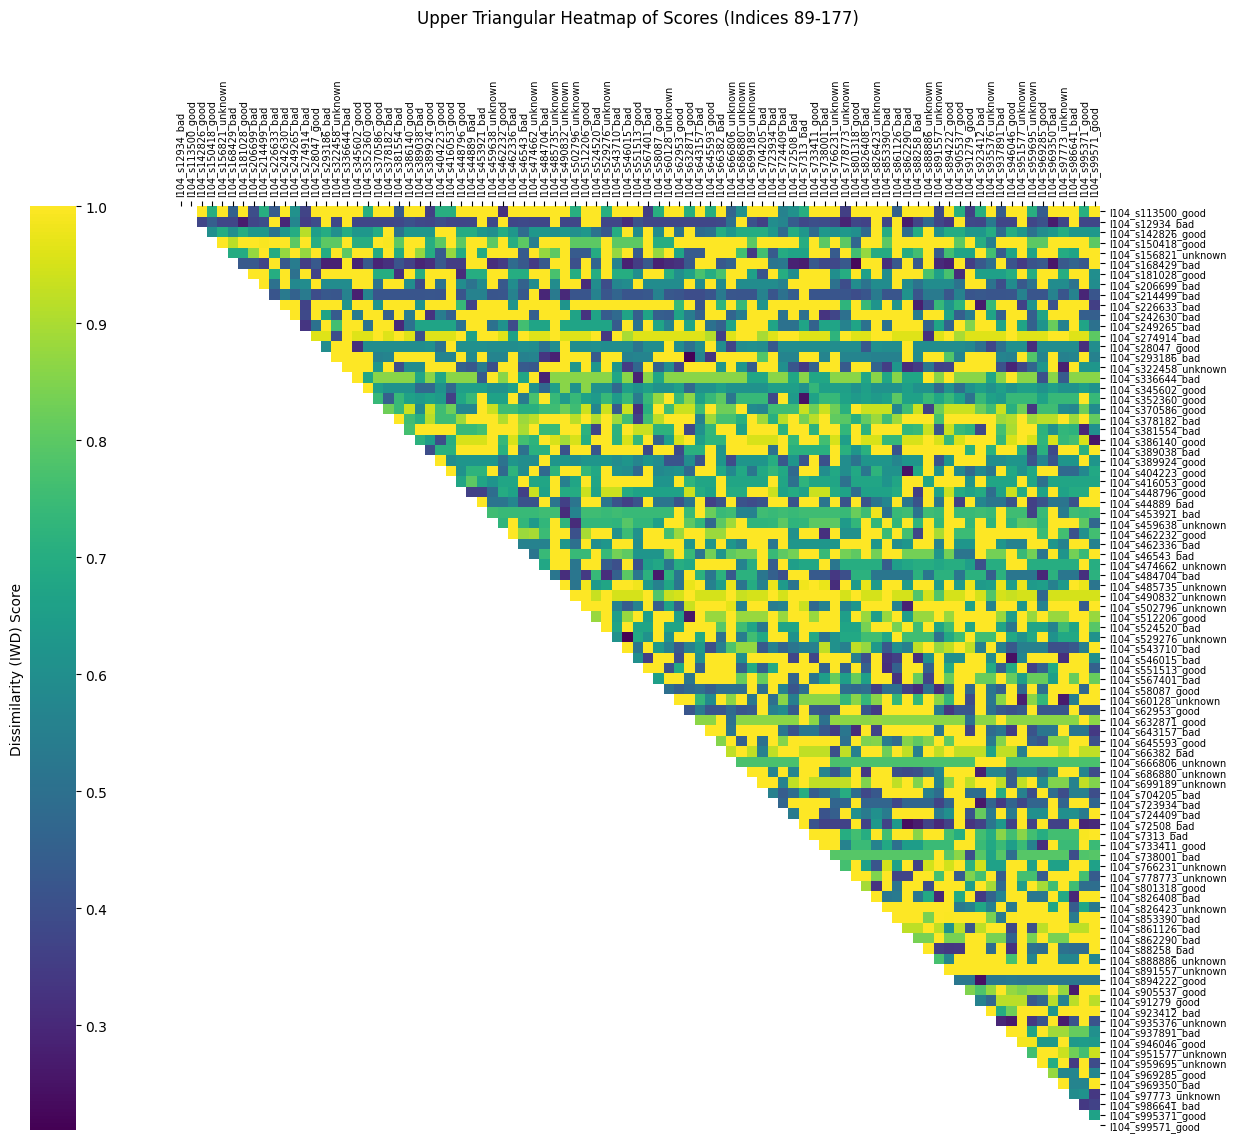

Trimmed shape: (89, 89)


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Use .iloc for proper integer-based slicing of the DataFrame (89:)
trimmed_scores = scores_df.iloc[89:, 89:]

# Create a mask for the lower triangle
mask = np.tril(np.ones_like(trimmed_scores, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))

# To put the colorbar on the left, we create a divider
divider = make_axes_locatable(ax)
cax = divider.append_axes("left", size="5%", pad=1.0)

# Plot the heatmap
sns.heatmap(
    trimmed_scores,
    mask=mask,
    cmap='viridis',
    annot=False,
    cbar=True,
    cbar_ax=cax,
    square=True,
    xticklabels=True,
    yticklabels=True,
    ax=ax
)

# Configure colorbar to show label on the left of it
cax.yaxis.set_label_position('left')
cax.set_ylabel('Dissimilarity (IWD) Score')

# Adjust tick parameters:
# X labels on top only
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
# Y labels on right only
ax.tick_params(left=False, labelleft=False, right=True, labelright=True)

ax.set_title('Upper Triangular Heatmap of Scores (Indices 89-177)', pad=40)
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)

plt.show()

print(f"Trimmed shape: {trimmed_scores.shape}")

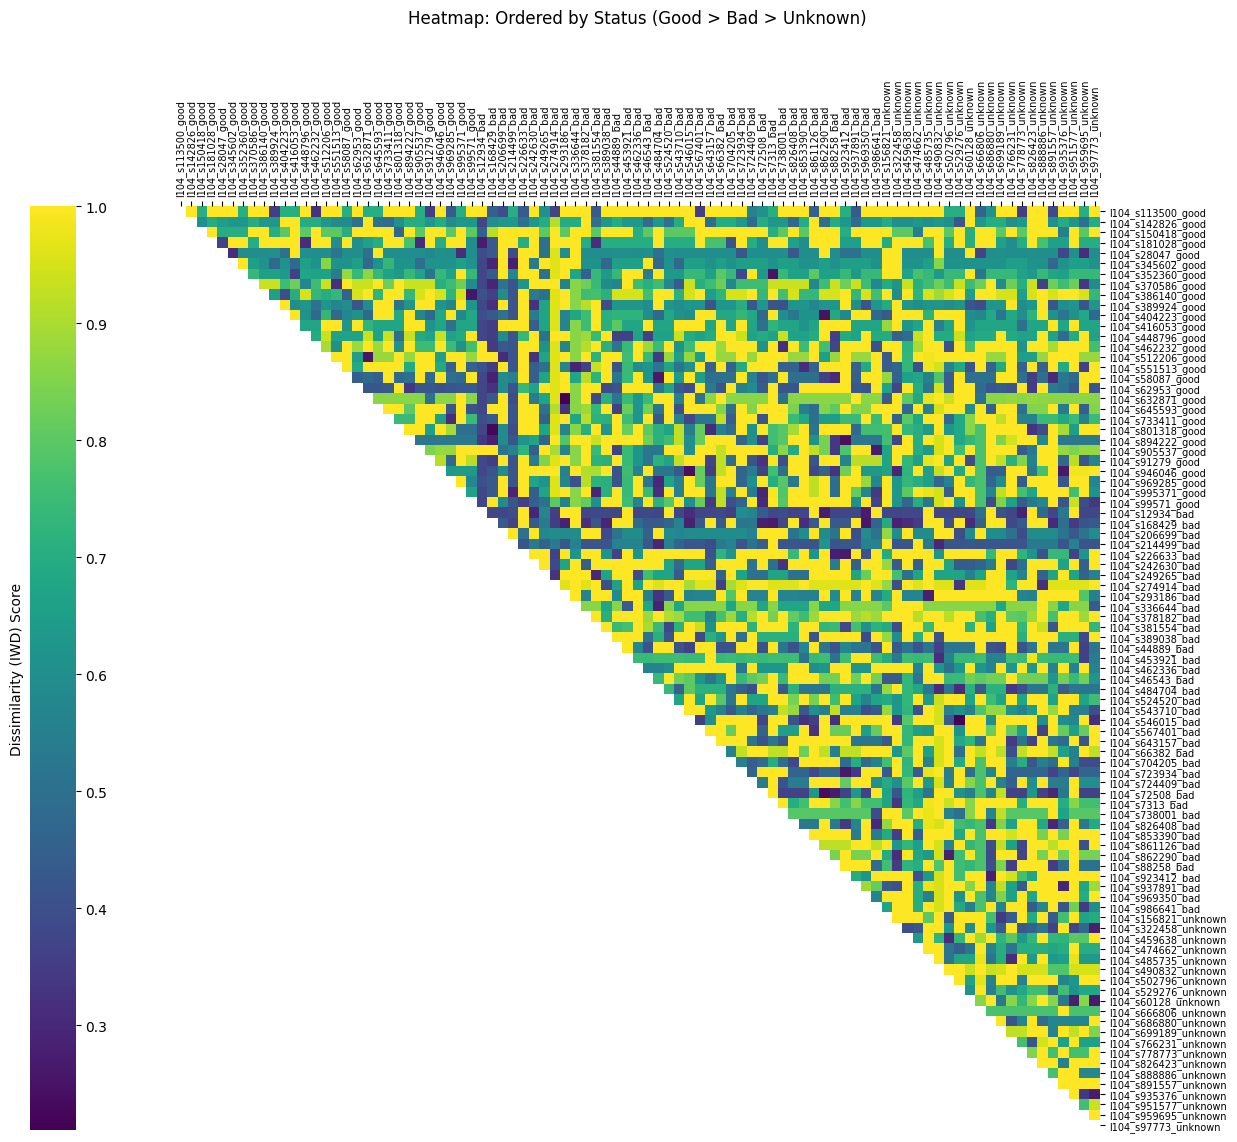

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1. Define custom sorting order
def get_status_priority(label):
    if '_good' in label.lower(): return 0
    if '_bad' in label.lower(): return 1
    return 2 # for 'unknown'

# 2. Get the indices from the trimmed portion (89:)
trimmed_indices = scores_df.index[89:].tolist()

# 3. Sort indices based on priority
sorted_labels = sorted(trimmed_indices, key=get_status_priority)

# 4. Reindex the DataFrame using the sorted labels
# We slice first to 89: and then reorder
ordered_scores = scores_df.loc[sorted_labels, sorted_labels]

# 5. Create mask for the lower triangle
mask = np.tril(np.ones_like(ordered_scores, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))

# Colorbar on the left
divider = make_axes_locatable(ax)
cax = divider.append_axes("left", size="5%", pad=1.0)

# Plot heatmap
sns.heatmap(
    ordered_scores,
    mask=mask,
    cmap='viridis',
    annot=False,
    cbar=True,
    cbar_ax=cax,
    square=True,
    xticklabels=True,
    yticklabels=True,
    ax=ax
)

cax.yaxis.set_label_position('left')
cax.set_ylabel('Dissimilarity (IWD) Score')

# X labels on top, Y labels on right
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax.tick_params(left=False, labelleft=False, right=True, labelright=True)

ax.set_title('Heatmap: Ordered by Status (Good > Bad > Unknown)', pad=40)
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)

plt.show()

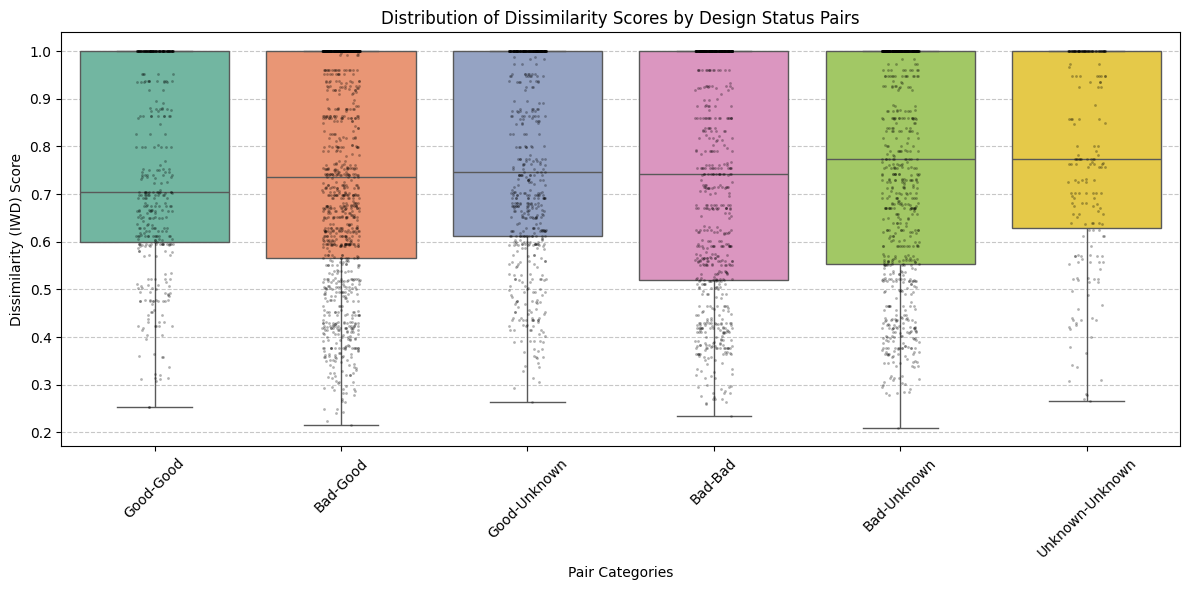

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Use the ordered_scores from the previous step
labels = ordered_scores.index
data = ordered_scores.values

# 2. Extract pairs and their statuses
results = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        val = data[i, j]
        if not np.isnan(val):
            # Determine the status of both designs in the pair
            s1 = 'Good' if '_good' in labels[i].lower() else 'Bad' if '_bad' in labels[i].lower() else 'Unknown'
            s2 = 'Good' if '_good' in labels[j].lower() else 'Bad' if '_bad' in labels[j].lower() else 'Unknown'

            # Sort pair names to group them (e.g., 'Bad-Good' becomes 'Good-Bad')
            pair_type = "-".join(sorted([s1, s2]))
            results.append({'Pair Type': pair_type, 'Dissimilarity Score': val})

viz_df = pd.DataFrame(results)

# 3. Plotting the distributions
plt.figure(figsize=(12, 6))
# Updated palette logic to resolve the FutureWarning
sns.boxplot(data=viz_df, x='Pair Type', y='Dissimilarity Score', hue='Pair Type', palette='Set2', legend=False)
sns.stripplot(data=viz_df, x='Pair Type', y='Dissimilarity Score', color='black', alpha=0.3, size=2)

plt.title('Distribution of Dissimilarity Scores by Design Status Pairs')
plt.ylabel('Dissimilarity (IWD) Score')
plt.xlabel('Pair Categories')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import os

# Assuming scores.npy is in the project_path
scores_filepath = os.path.join(project_path, 'scores2.pkl')

scores_df2 = pd.read_pickle(scores_filepath)

In [23]:
scores_df2

,l104_s62953_good,l104_s448796_good,l104_s462232_good,l104_s645593_good,l104_s905537_good,l104_s142826_good,l104_s91279_good,l104_s370586_good,l104_s404223_good,l104_s58087_good,...,PDL1_l104_s937891,PDL1_l104_s946046,PDL1_l104_s951577,PDL1_l104_s959695,PDL1_l104_s969285,PDL1_l104_s969350,PDL1_l104_s97773,PDL1_l104_s986641,PDL1_l104_s995371,PDL1_l104_s99571
l104_s62953_good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
l104_s448796_good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
l104_s462232_good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
l104_s645593_good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
l104_s905537_good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PDL1_l104_s969350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.886450,0.634962,1.000000,0.696305,0.874388,NaN,1.000000,0.567661,0.567661,1.000000
PDL1_l104_s97773,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.886450,1.000000,0.936195,1.000000,0.572954,1.000000,NaN,0.591838,0.611743,0.338595
PDL1_l104_s986641,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.813967,0.634962,0.827350,0.345979,0.572954,0.567661,0.591838,NaN,0.342165,0.367403
PDL1_l104_s995371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.813967,0.643814,0.762439,1.000000,1.000000,0.567661,0.611743,0.342165,NaN,0.664203


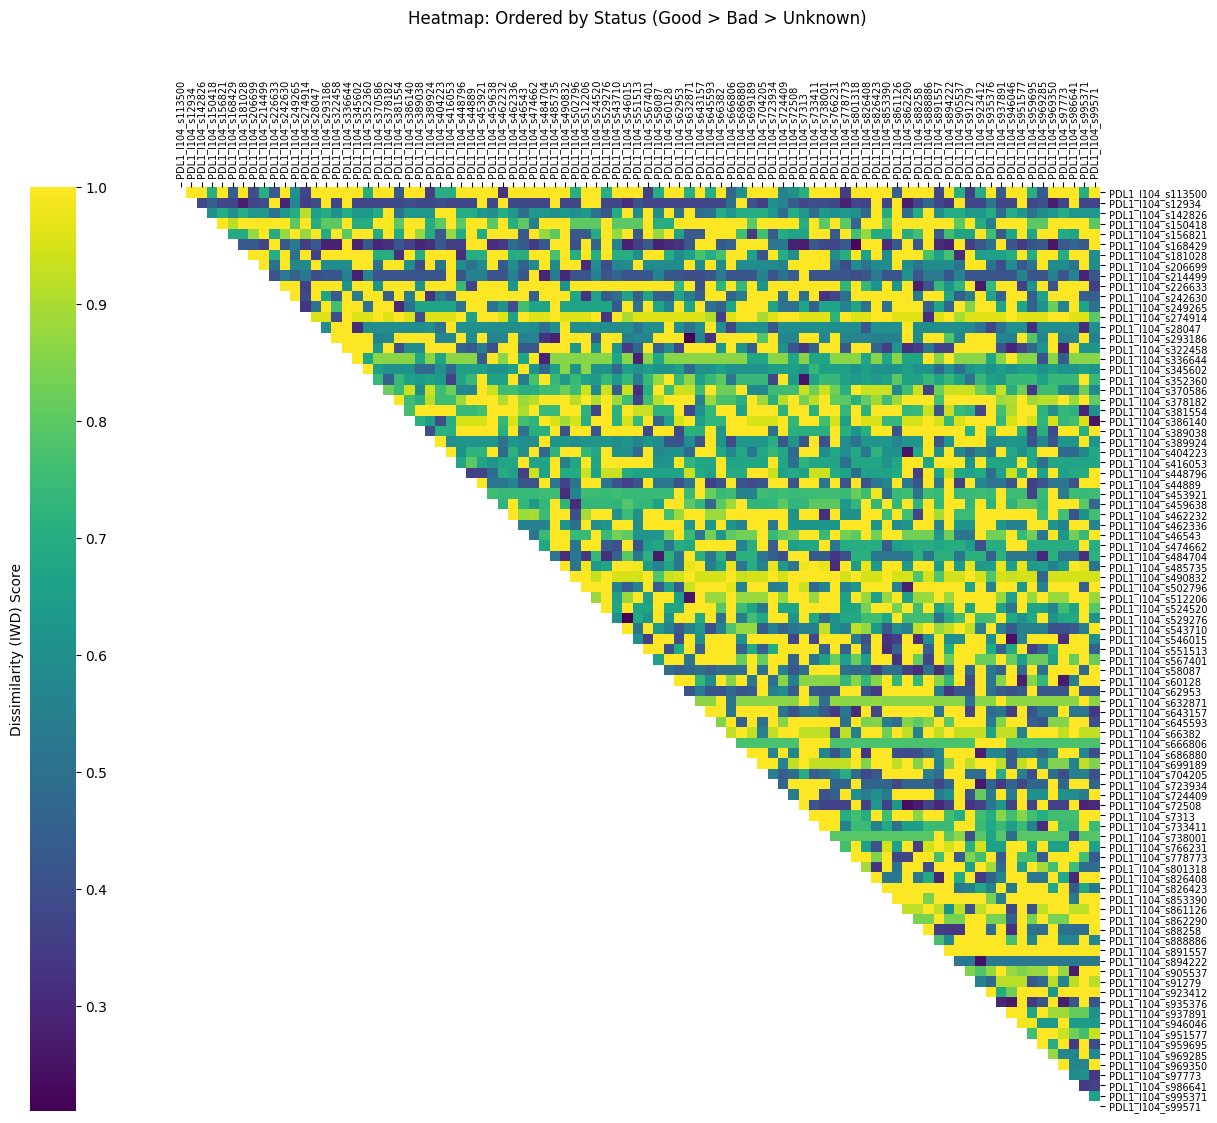

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1. Define custom sorting order
def get_status_priority(label):
    if '_good' in label.lower(): return 0
    if '_bad' in label.lower(): return 1
    return 2 # for 'unknown'

# 2. Get the indices from the trimmed portion (89:)
trimmed_indices = scores_df2.index[89:].tolist()

# 3. Sort indices based on priority
sorted_labels = sorted(trimmed_indices, key=get_status_priority)

# 4. Reindex the DataFrame using the sorted labels
# We slice first to 89: and then reorder
ordered_scores = scores_df2.loc[sorted_labels, sorted_labels]

# 5. Create mask for the lower triangle
mask = np.tril(np.ones_like(ordered_scores, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))

# Colorbar on the left
divider = make_axes_locatable(ax)
cax = divider.append_axes("left", size="5%", pad=1.0)

# Plot heatmap
sns.heatmap(
    ordered_scores,
    mask=mask,
    cmap='viridis',
    annot=False,
    cbar=True,
    cbar_ax=cax,
    square=True,
    xticklabels=True,
    yticklabels=True,
    ax=ax
)

cax.yaxis.set_label_position('left')
cax.set_ylabel('Dissimilarity (IWD) Score')

# X labels on top, Y labels on right
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax.tick_params(left=False, labelleft=False, right=True, labelright=True)

ax.set_title('Heatmap: Ordered by Status (Good > Bad > Unknown)', pad=40)
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)

plt.show()

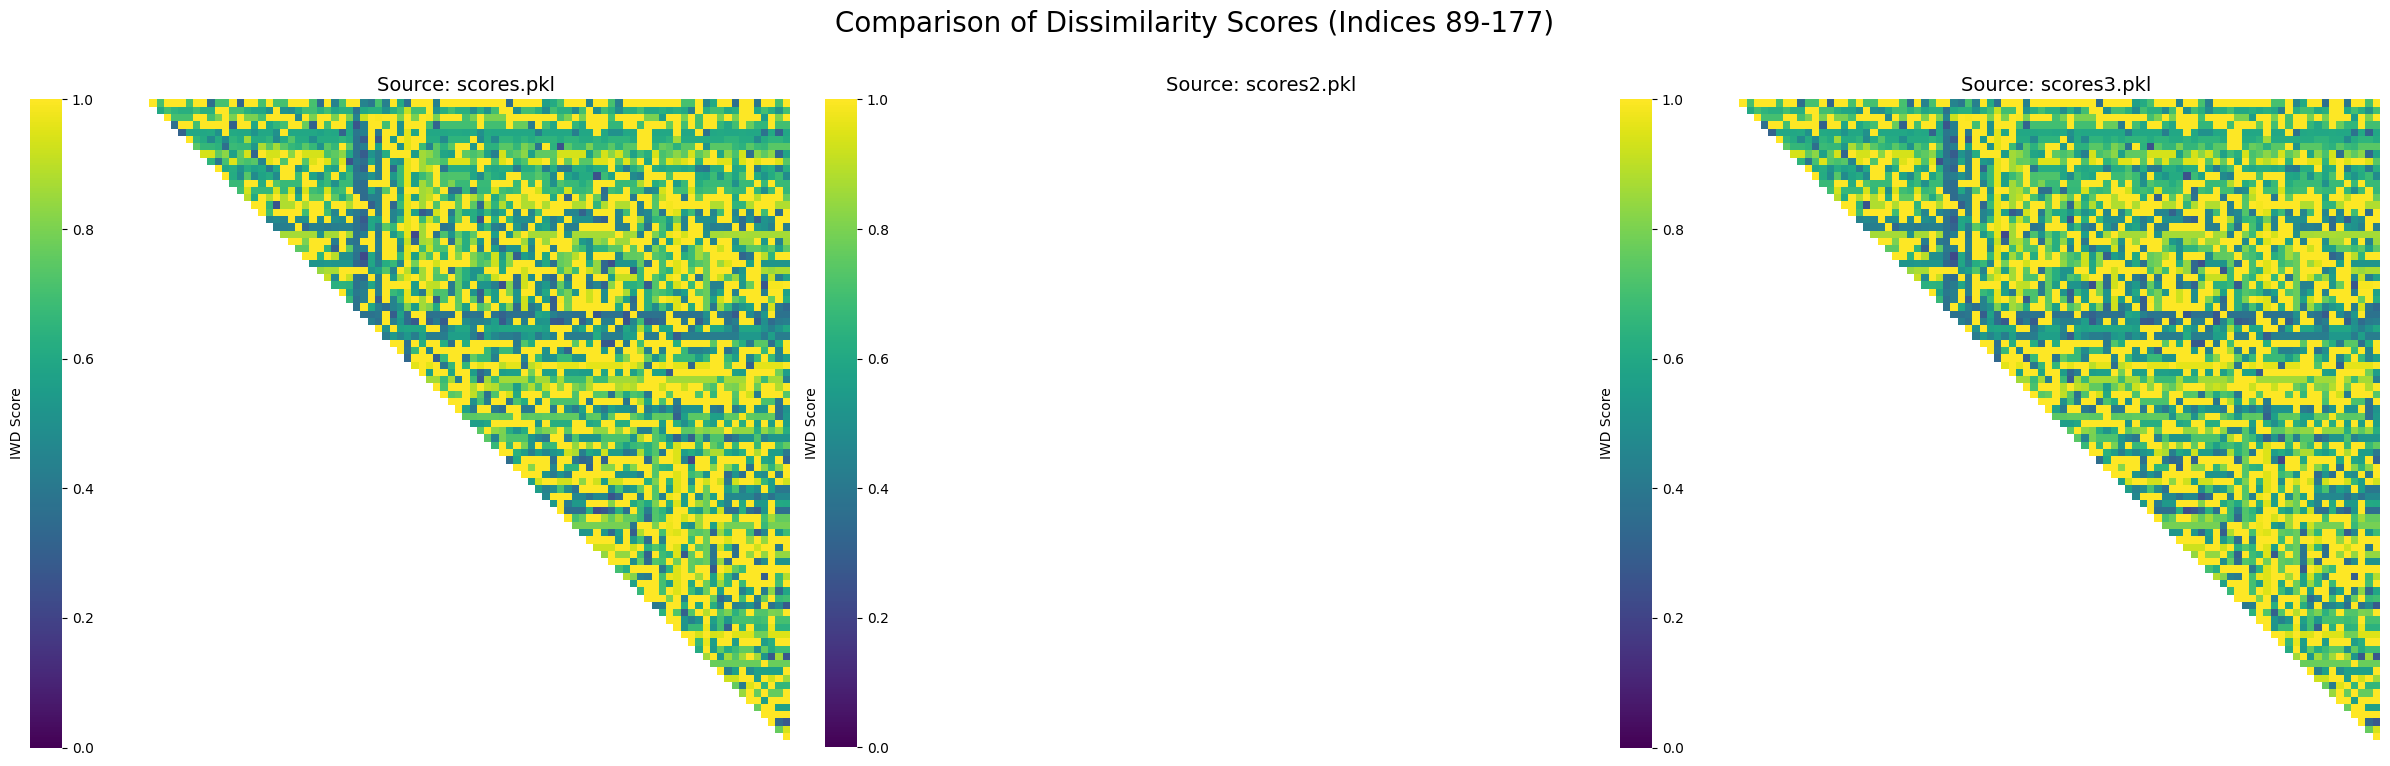

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1. Load the DataFrames
files = ['scores.pkl', 'scores2.pkl', 'scores3.pkl']
dataframes = []
for f in files:
    path = os.path.join(project_path, f)
    if os.path.exists(path):
        dataframes.append(pd.read_pickle(path))
    else:
        print(f"Warning: {f} not found.")

# 2. Define custom sorting order based on status
def get_status_priority(label):
    label_low = str(label).lower()
    if '_good' in label_low: return 0
    if '_bad' in label_low: return 1
    return 2 # for 'unknown'

# 3. Establish consistent ordering (using first available dataframe)
trimmed_indices = dataframes[0].index[89:].tolist()
sorted_labels = sorted(trimmed_indices, key=get_status_priority)

# 4. Set up the figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('Comparison of Dissimilarity Scores (Indices 89-177)', fontsize=20)

for i, df_raw in enumerate(dataframes):
    ax = axes[i]

    # Reorder the specific slice
    # Use .loc to ensure we pick existing labels in case of slight index variations
    available_labels = [l for l in sorted_labels if l in df_raw.index]
    ordered_scores = df_raw.loc[available_labels, available_labels]

    # Create mask for the lower triangle
    mask = np.tril(np.ones_like(ordered_scores, dtype=bool))

    # Create a divider for the colorbar on the left
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("left", size="5%", pad=0.8)

    # Plot heatmap with fixed vmin/vmax to avoid NaN scaling warnings
    sns.heatmap(
        ordered_scores,
        mask=mask,
        cmap='viridis',
        vmin=0,
        vmax=1,
        cbar=True,
        cbar_ax=cax,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=ax
    )

    cax.yaxis.set_label_position('left')
    cax.set_ylabel('IWD Score')

    ax.set_title(f'Source: {files[i]}', fontsize=14)

    # Set tick parameters: X on top, Y on right
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.tick_params(left=False, labelleft=False, right=True, labelright=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [26]:
import pandas as pd
import os

# Assuming scores.npy is in the project_path
scores_filepath = os.path.join(project_path, 'scores3.pkl')

scores_df3 = pd.read_pickle(scores_filepath)
scores_df3

,l104_s62953_good,l104_s448796_good,l104_s462232_good,l104_s645593_good,l104_s905537_good,l104_s142826_good,l104_s91279_good,l104_s370586_good,l104_s404223_good,l104_s58087_good,...,l104_s959695_unknown,l104_s666806_unknown,l104_s97773_unknown,l104_s474662_unknown,l104_s459638_unknown,l104_s778773_unknown,l104_s891557_unknown,l104_s699189_unknown,l104_s322458_unknown,l104_s529276_unknown
l104_s62953_good,NaN,0.664296,0.880725,0.422725,0.422725,0.507256,0.422725,0.936693,0.613063,0.446249,...,1.000000,0.483573,0.422725,0.702412,1.000000,1.000000,0.531975,0.435648,0.375699,1.000000
l104_s448796_good,0.664296,NaN,0.692742,0.664296,0.692742,0.697299,0.664296,0.572887,0.613539,0.664296,...,1.000000,0.692742,0.664296,0.935515,0.488565,0.664296,0.664296,1.000000,0.452551,0.935515
l104_s462232_good,0.880725,0.692742,NaN,0.880725,0.749645,0.697299,0.749645,0.753458,0.478175,1.000000,...,1.000000,1.000000,0.760541,0.895336,0.725246,0.605297,0.895336,1.000000,1.000000,1.000000
l104_s645593_good,0.422725,0.664296,0.880725,NaN,1.000000,0.507256,1.000000,1.000000,1.000000,0.446249,...,0.448428,1.000000,0.853172,1.000000,0.473837,0.500203,1.000000,1.000000,1.000000,1.000000
l104_s905537_good,0.422725,0.692742,0.749645,1.000000,NaN,0.697299,0.846883,0.936693,0.580448,1.000000,...,0.874231,0.773045,0.874231,0.702412,1.000000,0.436262,0.999711,1.000000,1.000000,0.756610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
l104_s778773_unknown,1.000000,0.664296,0.605297,0.500203,0.436262,0.629810,0.846126,0.709351,0.593683,0.495494,...,0.762961,0.773045,1.000000,0.702412,0.637661,NaN,0.762961,0.923803,0.430585,0.682457
l104_s891557_unknown,0.531975,0.664296,0.895336,1.000000,0.999711,0.599372,0.999711,0.825544,0.613063,0.306759,...,1.000000,0.773045,1.000000,0.680183,0.729519,0.762961,NaN,0.558271,0.366511,0.497292
l104_s699189_unknown,0.435648,1.000000,1.000000,1.000000,1.000000,0.697299,0.923803,0.587632,0.521623,1.000000,...,1.000000,0.773045,0.849380,0.702412,0.725246,0.923803,0.558271,NaN,0.439800,0.756610
l104_s322458_unknown,0.375699,0.452551,1.000000,1.000000,1.000000,0.599372,1.000000,0.625546,1.000000,0.459425,...,0.467084,1.000000,0.279703,0.424481,0.399848,0.430585,0.366511,0.439800,NaN,1.000000


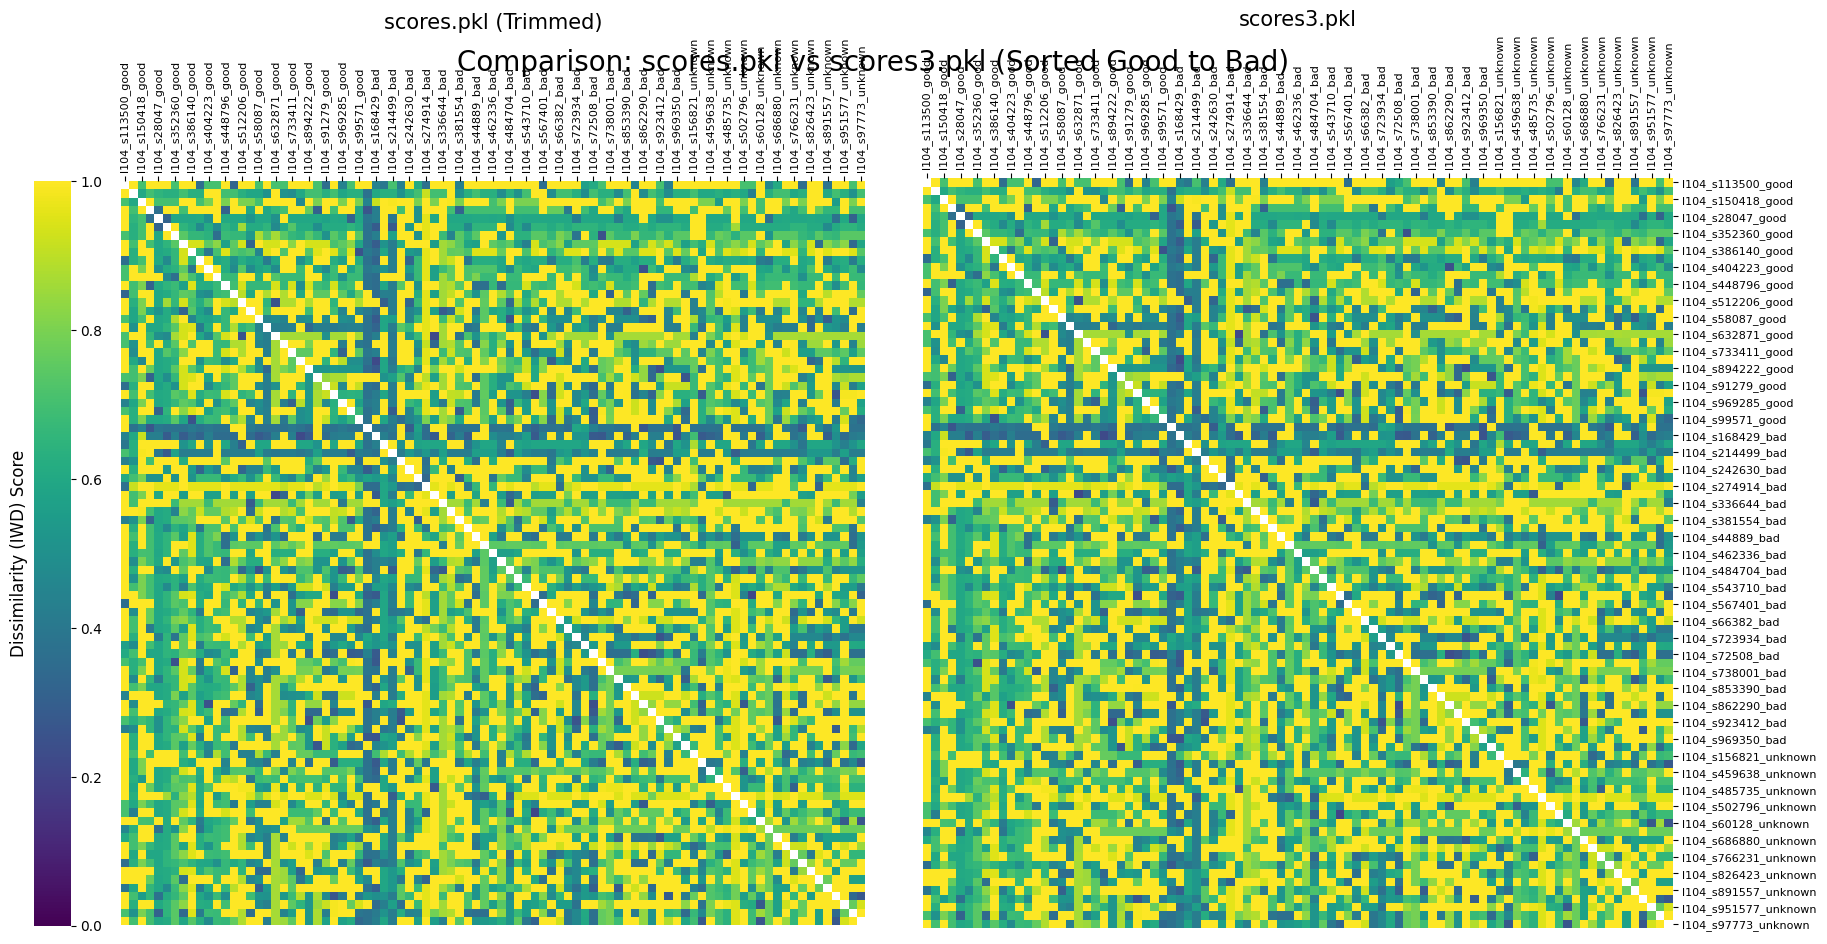

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1. Define custom sorting order
def get_status_priority(label):
    label_low = str(label).lower()
    if '_good' in label_low: return 0
    if '_bad' in label_low: return 1
    return 2

# 2. Load and Prepare Data
path1 = os.path.join(project_path, 'scores.pkl')
path3 = os.path.join(project_path, 'scores3.pkl')

# scores.pkl: load, trim to 89:, and sort
df1_raw = pd.read_pickle(path1)
trimmed_indices1 = df1_raw.index[89:].tolist()
sorted_labels = sorted(trimmed_indices1, key=get_status_priority)
scores1 = df1_raw.loc[sorted_labels, sorted_labels]

# scores3.pkl: load and sort using the same logic
scores3_raw = pd.read_pickle(path3)
available_labels3 = [l for l in sorted_labels if l in scores3_raw.index]
scores3 = scores3_raw.loc[available_labels3, available_labels3]

# 3. Plotting with minimal spacing
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle('Comparison: scores.pkl vs scores3.pkl (Sorted Good to Bad)', fontsize=20)

# Create a single shared colorbar on the far left
divider = make_axes_locatable(ax1)
cax = divider.append_axes("left", size="5%", pad=0.5)

# Plot Heatmap 1
sns.heatmap(
    scores1,
    cmap='viridis',
    vmin=0, vmax=1,
    cbar=True,
    cbar_ax=cax,
    square=True,
    ax=ax1
)
ax1.set_title('scores.pkl (Trimmed)', fontsize=15)

# Plot Heatmap 2
sns.heatmap(
    scores3,
    cmap='viridis',
    vmin=0, vmax=1,
    cbar=False,
    square=True,
    ax=ax2
)
ax2.set_title('scores3.pkl', fontsize=15)

# Configure Labels: Remove Y labels on left plot, keep X on top, Y on right for second plot
ax1.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False, left=False, labelleft=False)
ax2.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False, left=False, labelleft=False, right=True, labelright=True)

# Rotate and format all labels
for ax in [ax1, ax2]:
    plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)

cax.yaxis.set_label_position('left')
cax.set_ylabel('Dissimilarity (IWD) Score', fontsize=12)

# Tightly pack the subplots
plt.subplots_adjust(wspace=0.02, left=0.08, right=0.92, top=0.85, bottom=0.1)
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


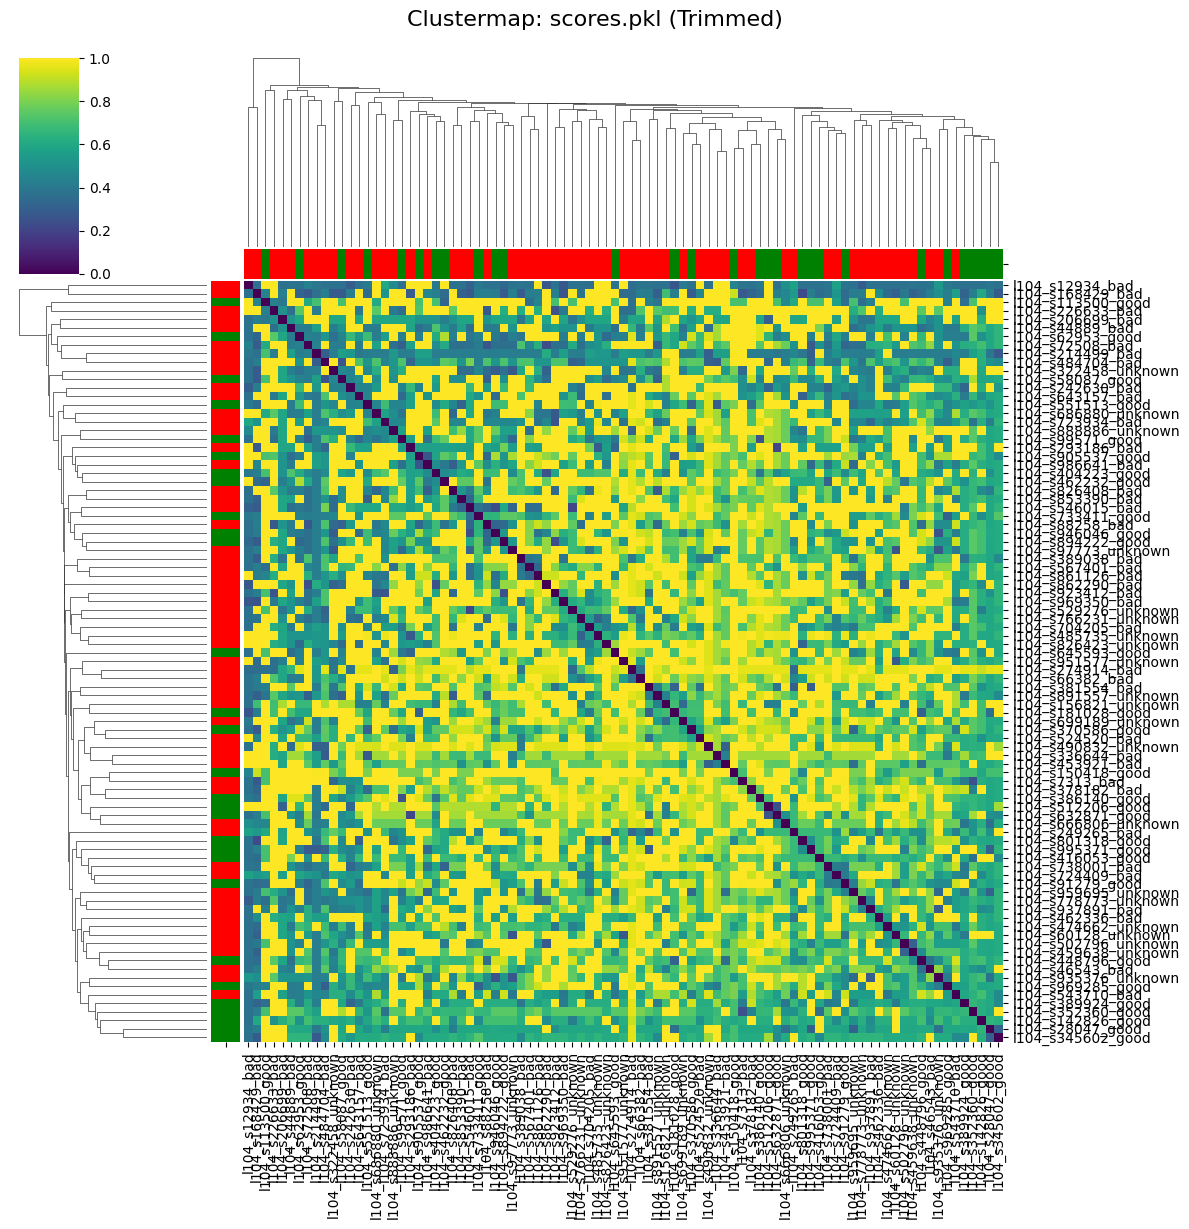

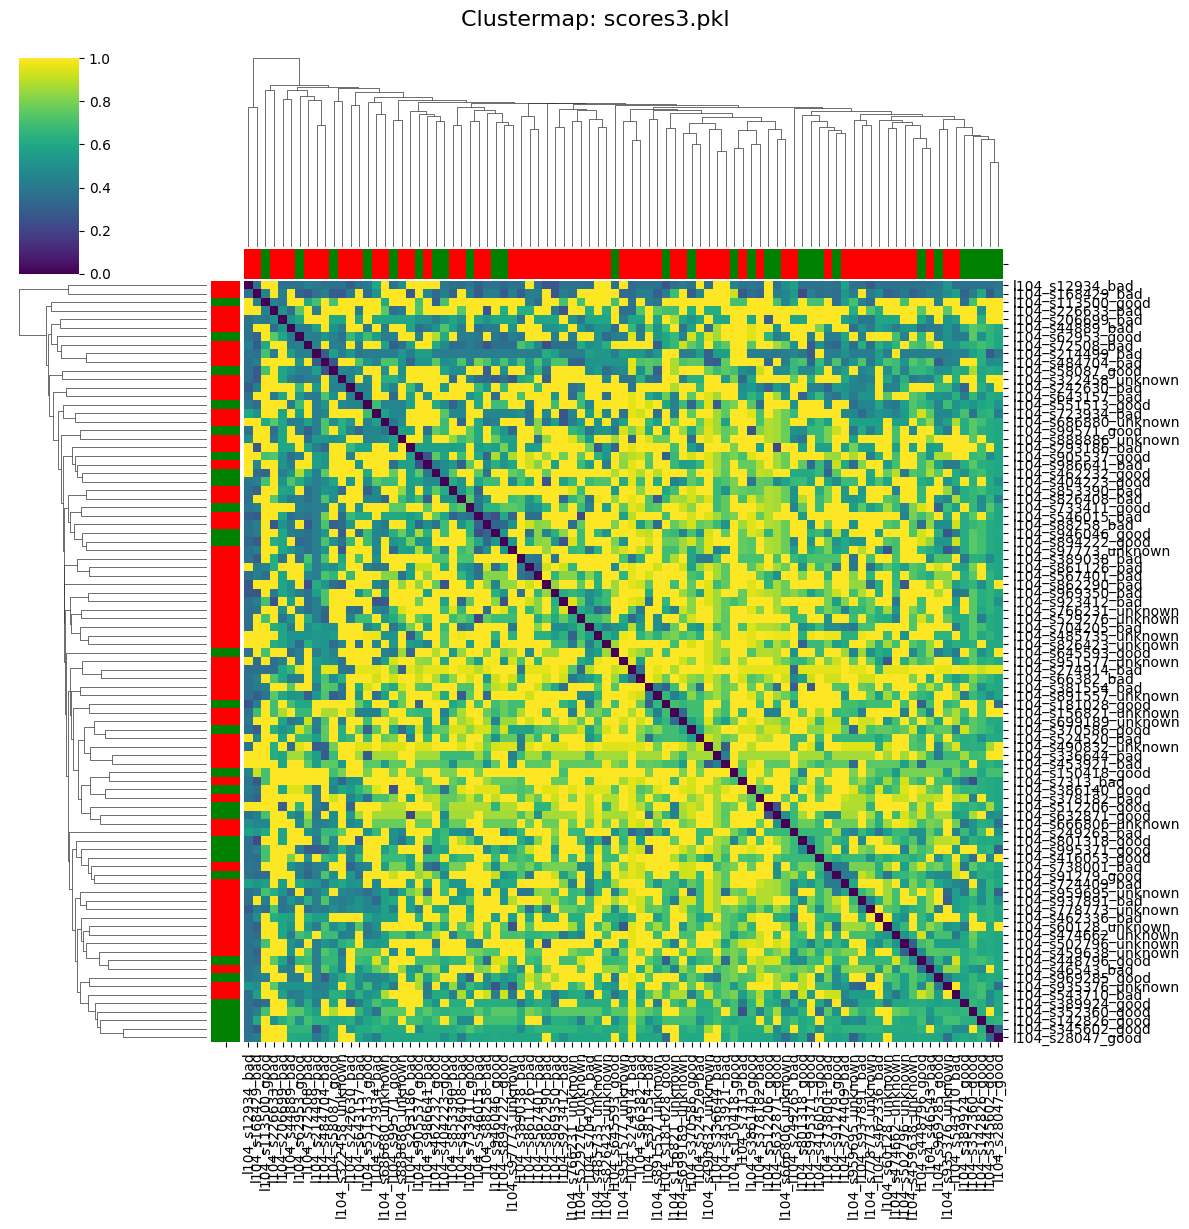

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

# 1. Prepare Data
path1 = os.path.join(project_path, 'scores.pkl')
path3 = os.path.join(project_path, 'scores3.pkl')

# scores.pkl: load and trim
df1_raw = pd.read_pickle(path1)
scores1 = df1_raw.iloc[89:, 89:]

# scores3.pkl: load
scores3 = pd.read_pickle(path3)

# 2. Define Helper for Status Colors
def get_status_colors(indices):
    colors = []
    for label in indices:
        l = str(label).lower()
        if '_good' in l: colors.append('green')
        else: colors.append('red')
    return pd.Series(colors, index=indices)

# 3. Clustermap for scores.pkl
colors1 = get_status_colors(scores1.index)
g1 = sns.clustermap(
    scores1.fillna(0),
    cmap='viridis',
    vmin=0, vmax=1,
    figsize=(12, 12),
    row_colors=colors1,
    col_colors=colors1,
    xticklabels=True,
    yticklabels=True
)
g1.fig.suptitle('Clustermap: scores.pkl (Trimmed)', y=1.02, fontsize=16)

# 4. Clustermap for scores3.pkl
colors3 = get_status_colors(scores3.index)
g3 = sns.clustermap(
    scores3.fillna(0),
    cmap='viridis',
    vmin=0, vmax=1,
    figsize=(12, 12),
    row_colors=colors3,
    col_colors=colors3,
    xticklabels=True,
    yticklabels=True
)
g3.fig.suptitle('Clustermap: scores3.pkl', y=1.02, fontsize=16)

plt.show()

In [29]:
scores1['l104_s345602_good']['l104_s28047_good']

np.float64(0.31394470010035175)

In [32]:
np.sort(scores1.values.flatten())

array([0.21040966, 0.21040966, 0.21498752, ...,        nan,        nan,
              nan])